# H9MLAI — Intelligent Proactive Resource Forecasting for Cloud-Native Systems
### A Multi-Model Machine Learning Approach to CPU and Memory Forecasting, SLA Prediction, and Cross-Cloud Cost Optimisation

---

| Field | Details |
|---|---|
| **Student** | Sabhyata Kumari |
| **Student ID** | X24283142 |
| **Programme** | MSc Artificial Intelligence (MSCAI1) |
| **Institution** | National College of Ireland |
| **Module** | H9MLAI — Machine Learning |
| **Academic Year** | 2025/2026 |

---
## Section 1 — Notebook Setup

This section loads the core Python libraries used throughout the notebook and prepares the output folders needed for figures, processed data, models, and results.


### 1.1 Core imports and display configuration


In [158]:
# ── 1.1  Core imports and display configuration ──────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib, json, time
from IPython.display import display, Image

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# Create output folders used later in the notebook
for folder in ['data/processed', 'data/models', 'data/results', 'data/figures']:
    Path(folder).mkdir(parents=True, exist_ok=True)
print('Core imports OK')


Core imports OK


---
## Section 2 — Raw Data Loading

Three real-world cloud workload datasets are loaded **exactly as they are on disk** — no transformations applied yet.

| Dataset | Provider | Rows | Sampling Interval | Role |
|---|---|---|---|---|
| **Alibaba 2018 Cluster Trace** | Alibaba | ~500K | 10 min | Primary training |
| **Azure VM CPU Readings** | Microsoft Azure | ~200K | 5 min | Cross-cloud validation |
| **Google Cluster Traces v3** | Google | ~150K | Variable | Cross-cloud test |

**Submission note:** the notebook reads the extracted dataset files from `data/raw/` during development, but the project submission will include the data in zipped form rather than uploading the standalone CSV files separately.

The raw CSV files are extracted from their original public sources, and the modelling pipeline can still run from the processed files in `data/processed/` when the full raw CSVs are not included locally.


### 2.1 Load Alibaba raw CSV (zero preprocessing)

In [159]:
# ── 2.1  Load Alibaba raw CSV (zero preprocessing) ───────────────────────────
ali_raw_path = Path('data/raw/alibaba/machine_usage.csv')

if ali_raw_path.exists():
    ali_raw = pd.read_csv(ali_raw_path, header=None, nrows=50000)
    ali_raw.columns = ['node_id','ts','cpu','mem','col_5','col_6','net_in','net_out','disk_io'][:len(ali_raw.columns)]
    print(f'Alibaba raw sample shape : {ali_raw.shape}')
    print(f'Column names            : {list(ali_raw.columns)}')
    print(f'Dtypes:\n{ali_raw.dtypes}\n')
    print('━━━━━ First 5 rows (RAW sample, no preprocessing) ━━━━━')
    display(ali_raw.head(5))
    print('\n━━━━━ Missing values per column in sample ━━━━━')
    display(ali_raw.isnull().sum().to_frame('null_count').T)
    print(f'\nTotal null cells in sample: {ali_raw.isnull().sum().sum():,}')
else:
    print('⚠  Alibaba raw file not found — run: python setup_and_download.py')
    ali_raw = None

Alibaba raw sample shape : (50000, 9)
Column names            : ['node_id', 'ts', 'cpu', 'mem', 'col_5', 'col_6', 'net_in', 'net_out', 'disk_io']
Dtypes:
node_id     object
ts           int64
cpu          int64
mem          int64
col_5      float64
col_6      float64
net_in     float64
net_out    float64
disk_io      int64
dtype: object

━━━━━ First 5 rows (RAW sample, no preprocessing) ━━━━━


,node_id,ts,cpu,mem,col_5,col_6,net_in,net_out,disk_io
0,m_1932,386640,41,92,NaN,NaN,43.0400,33.0800,5
1,m_1932,386670,43,92,NaN,NaN,43.0400,33.0800,5
2,m_1932,386690,44,92,NaN,NaN,43.0500,33.0800,5
3,m_1932,386800,46,92,NaN,NaN,43.0500,33.0800,3
4,m_1932,386930,44,93,NaN,NaN,43.0500,33.0900,4



━━━━━ Missing values per column in sample ━━━━━


,node_id,ts,cpu,mem,col_5,col_6,net_in,net_out,disk_io
null_count,0,0,0,0,39809,39809,0,0,0



Total null cells in sample: 79,618


### 2.2 Load Azure raw CSV

In [160]:
# ── 2.2  Load Azure raw CSV ────────────────────────────────────────────────────
azure_raw_path  = Path('data/raw/azure/vm_cpu_readings.csv')
azure_raw_pathz = Path('data/raw/azure/vm_cpu_readings.csv.gz')

if azure_raw_path.exists():
    azure_raw = pd.read_csv(azure_raw_path, header=None, nrows=50000)
elif azure_raw_pathz.exists():
    try:
        azure_raw = pd.read_csv(azure_raw_pathz, compression='gzip', header=None, nrows=50000,
                                 on_bad_lines='skip')
    except Exception as e:
        print(f'  Gzip read error: {e}')
        azure_raw = None
else:
    azure_raw = None

if azure_raw is not None:
    azure_raw.columns = ['ts','node_id','cpu_min','cpu_max','cpu'][:len(azure_raw.columns)]
    print(f'Azure raw sample shape : {azure_raw.shape}')
    print(f'Column names          : {list(azure_raw.columns)}')
    display(azure_raw.head(5))
    print('\n━━━━━ Missing values in sample ━━━━━')
    display(azure_raw.isnull().sum().to_frame('null_count').T)
else:
    print('⚠  Azure raw file not found')

Azure raw sample shape : (50000, 5)
Column names          : ['ts', 'node_id', 'cpu_min', 'cpu_max', 'cpu']


,ts,node_id,cpu_min,cpu_max,cpu
0,0,yNf/R3X8fyXkOJm3ihXQcT0F52a8cDWPPRzTT6QFW8N+1Q...,19.8984,24.9964,22.6307
1,0,gVb4X4iS13nJrM0KZsy7SrHzWAHix0CEPlK7/deV5vkwjt...,14.2815,20.0283,17.2507
2,0,f8BtQHczrXFjnVxWl8Hqm1kH9UD/8nCvtXCLiFvVRvamqa...,1.6554,23.1387,8.5338
3,0,8xjtVrJRJAyArNlbRgCftoNQOZiWl2eRP6uQavL9+6IULT...,47.5011,52.9406,50.0456
4,0,zTE3f0H2n43tW+PA3OdonjUTWWxeyzF7xJk9QH9s/487J/...,1.7242,12.8896,4.8336



━━━━━ Missing values in sample ━━━━━


,ts,node_id,cpu_min,cpu_max,cpu
null_count,0,0,0,0,0


### 2.3 Load Google raw CSV

In [161]:
# ── 2.3  Load Google raw CSV ───────────────────────────────────────────────────
goog_raw_path = Path('data/raw/google/machine_events.csv')
goog_alt_path = Path('data/raw/google/google_cluster_data_1.csv')

if goog_raw_path.exists():
    goog_raw = pd.read_csv(goog_raw_path, nrows=50000)
elif goog_alt_path.exists():
    goog_raw = pd.read_csv(goog_alt_path, sep=r'\s+', engine='python', nrows=50000)
    if len(goog_raw.columns) == 1:
        goog_raw = pd.read_csv(
            goog_alt_path,
            sep=' ',
            engine='python',
            skipinitialspace=True,
            nrows=50000,
        )
    print(f'Google raw sample shape : {goog_raw.shape}')
    print(f'Column names           : {list(goog_raw.columns)}')
    display(goog_raw.head(5))

    # Google stores CPU as 0-1 fractions
    if 'NrmlTaskCores' in goog_raw.columns:
        cpu_col = 'NrmlTaskCores'
    else:
        cpu_col = next((c for c in goog_raw.columns if 'cpu' in c.lower()), goog_raw.columns[-2])
    cpu_series = pd.to_numeric(goog_raw[cpu_col], errors='coerce').dropna()
    print(f'\nCPU column "{cpu_col}" range: {cpu_series.min():.4f} – {cpu_series.max():.4f}')
    if len(cpu_series) and cpu_series.max() <= 1.0:
        print('  ⚠  Values are fractional (0–1) — will be multiplied ×100 in preprocessing')
else:
    print('⚠  Google raw file not found')
    goog_raw = None


Google raw sample shape : (50000, 6)
Column names           : ['Time', 'ParentID', 'TaskID', 'JobType', 'NrmlTaskCores', 'NrmlTaskMem']


,Time,ParentID,TaskID,JobType,NrmlTaskCores,NrmlTaskMem
0,90000,757745334,1488529826,0,0.0000,0.0311
1,90000,975992247,1488529821,0,0.0000,0.0000
2,90000,1468458091,1488529832,1,0.0219,0.0024
3,90000,1460281235,1488529840,0,0.0000,0.0000
4,90000,1164728954,1488529835,0,0.0031,0.0016



CPU column "NrmlTaskCores" range: 0.0000 – 0.1250
  ⚠  Values are fractional (0–1) — will be multiplied ×100 in preprocessing


### 2.4 Raw dataset summary comparison

In [162]:
# ── 2.4  Raw dataset summary comparison ──────────────────────────────────────
summary_rows = []
for name, df in [('Alibaba', ali_raw   if 'ali_raw'   in dir() else None),
                  ('Azure',   azure_raw if 'azure_raw' in dir() else None),
                  ('Google',  goog_raw  if 'goog_raw'  in dir() else None)]:
    if df is not None:
        summary_rows.append({
            'Dataset':       name,
            'Rows':          f'{len(df):,}',
            'Columns':       len(df.columns),
            'Column names':  ', '.join(df.columns[:5].tolist()),
            'Total nulls':   df.isnull().sum().sum(),
            'Memory (MB)':   f"{df.memory_usage(deep=True).sum()/1e6:.1f}",
        })

print('\n══════════════════ RAW DATA SAMPLE SUMMARY ══════════════════')
display(pd.DataFrame(summary_rows).set_index('Dataset'))
print('\nNote: This section uses manageable raw-data samples for inspection. Later modelling sections also use notebook-sized subsets so the full pipeline stays reproducible and Colab-friendly.')


══════════════════ RAW DATA SAMPLE SUMMARY ══════════════════


,Rows,Columns,Column names,Total nulls,Memory (MB)
Dataset,,,,,
Alibaba,"50,000",9,"node_id, ts, cpu, mem, col_5",79618,6.4
Azure,"50,000",5,"ts, node_id, cpu_min, cpu_max, cpu",0,7.7
Google,"50,000",6,"Time, ParentID, TaskID, JobType, NrmlTaskCores",0,2.4



Note: This section uses manageable raw-data samples for inspection. Later modelling sections also use notebook-sized subsets so the full pipeline stays reproducible and Colab-friendly.


### 2.5 Missing and null values by dataset

This subsection reports the missing or null count for **every column** in each raw dataset sample, along with the percentage of rows affected.


In [163]:
# ── 2.5  Missing and null values by dataset ──────────────────────────────
def missing_summary(df, name):
    summary = pd.DataFrame({
        'column': df.columns,
        'null_count': df.isnull().sum().values,
        'null_pct': (df.isnull().mean().values * 100).round(2),
        'dtype': [str(t) for t in df.dtypes],
    })
    summary = summary.sort_values(['null_count', 'column'], ascending=[False, True]).reset_index(drop=True)
    print(f'\n{name} - missing/null values by column')
    display(summary)

for name, df in [
    ('Alibaba', ali_raw if 'ali_raw' in dir() else None),
    ('Azure', azure_raw if 'azure_raw' in dir() else None),
    ('Google', goog_raw if 'goog_raw' in dir() else None),
]:
    if df is not None:
        missing_summary(df, name)



Alibaba - missing/null values by column


,column,null_count,null_pct,dtype
0,col_5,39809,79.6200,float64
1,col_6,39809,79.6200,float64
2,cpu,0,0.0000,int64
3,disk_io,0,0.0000,int64
4,mem,0,0.0000,int64
5,net_in,0,0.0000,float64
6,net_out,0,0.0000,float64
7,node_id,0,0.0000,object
8,ts,0,0.0000,int64



Azure - missing/null values by column


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,float64
1,cpu_max,0,0.0000,float64
2,cpu_min,0,0.0000,float64
3,node_id,0,0.0000,object
4,ts,0,0.0000,int64



Google - missing/null values by column


,column,null_count,null_pct,dtype
0,JobType,0,0.0000,int64
1,NrmlTaskCores,0,0.0000,float64
2,NrmlTaskMem,0,0.0000,float64
3,ParentID,0,0.0000,int64
4,TaskID,0,0.0000,int64
5,Time,0,0.0000,int64


---
## Section 3 — Exploratory Data Analysis (EDA)


### 3.1 Descriptive statistics — Alibaba raw CPU and memory

In [164]:
# ── 3.1  Descriptive statistics — Alibaba raw CPU and memory ──────────────────
if ali_raw is not None:
    cpu_col = next((c for c in ali_raw.columns if 'cpu' in c.lower()), ali_raw.columns[2])
    mem_col = next((c for c in ali_raw.columns if 'mem' in c.lower()), ali_raw.columns[3])

    print('━━━━━ Alibaba Raw Statistics ━━━━━')
    stats_df = ali_raw[[cpu_col, mem_col]].apply(pd.to_numeric, errors='coerce').describe()
    display(stats_df.round(2))

    cpu_s = pd.to_numeric(ali_raw[cpu_col], errors='coerce').dropna()
    pct_over_85 = (cpu_s > 85).mean() * 100
    print(f'\nCPU > 85% (SLA breach risk): {pct_over_85:.2f}% of all samples')
    print(f'Skewness of CPU:             {cpu_s.skew():.3f}  (positive = right-skewed)')
    print(f'Kurtosis of CPU:             {cpu_s.kurtosis():.3f}')

━━━━━ Alibaba Raw Statistics ━━━━━


,cpu,mem
count,50000.0000,50000.0000
mean,33.8800,90.3100
std,17.4000,5.0100
min,3.0000,52.0000
25%,24.0000,89.0000
50%,34.0000,92.0000
75%,45.0000,93.0000
max,93.0000,98.0000



CPU > 85% (SLA breach risk): 0.77% of all samples
Skewness of CPU:             0.267  (positive = right-skewed)
Kurtosis of CPU:             0.182


### 3.2 CPU distributions across all three providers

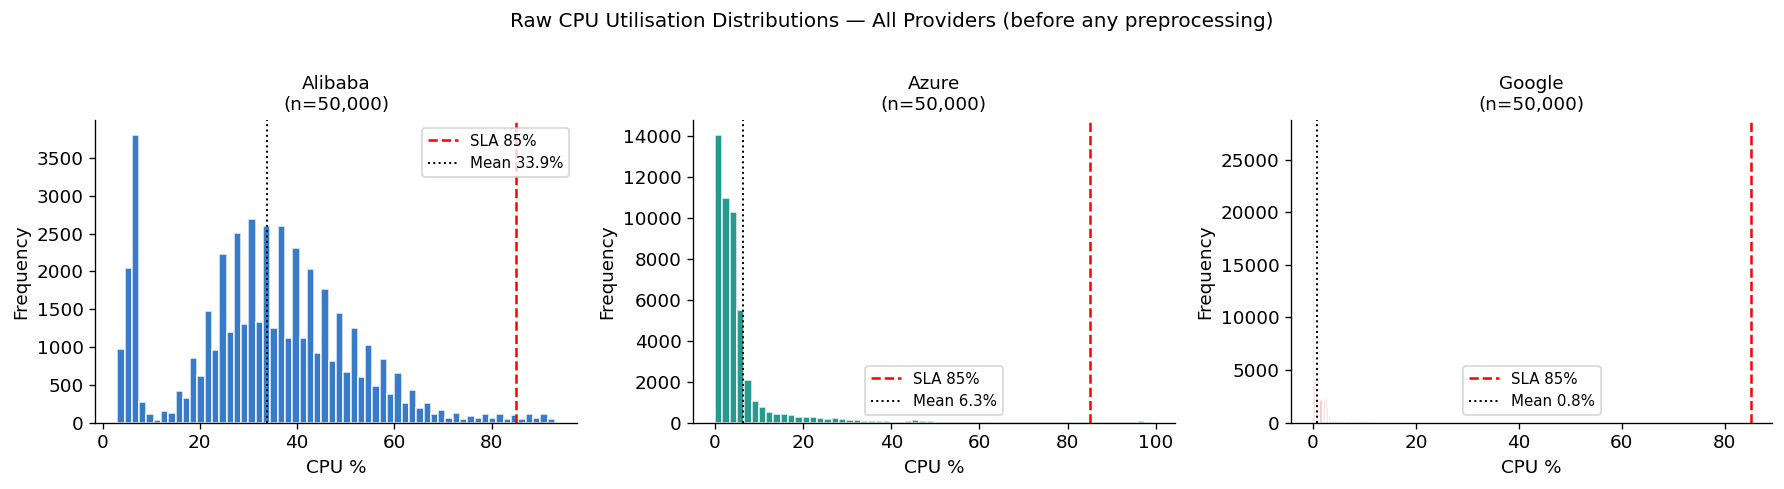

In [165]:
# ── 3.2  CPU distributions across all three providers ────────────────────────
datasets_raw = {}
for name, raw_df, col_hint in [
        ('Alibaba', ali_raw   if 'ali_raw'   in dir() else None, 'cpu'),
        ('Azure',   azure_raw if 'azure_raw' in dir() else None, 'cpu'),
        ('Google',  goog_raw  if 'goog_raw'  in dir() else None, 'cpu')]:
    if raw_df is None:
        continue
    if name == 'Google' and 'NrmlTaskCores' in raw_df.columns:
        col = 'NrmlTaskCores'
    else:
        col = next((c for c in raw_df.columns if col_hint in c.lower()), raw_df.columns[2])
    s   = pd.to_numeric(raw_df[col], errors='coerce').dropna()
    if s.max() <= 1.0:
        s = s * 100   # Google: convert fractions to percent
    datasets_raw[name] = s

colors = {'Alibaba': '#1565C0', 'Azure': '#00897B', 'Google': '#E53935'}
n_plots = len(datasets_raw)
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4), sharey=False)
if n_plots == 1: axes = [axes]

for ax, (name, series) in zip(axes, datasets_raw.items()):
    ax.hist(series, bins=60, color=colors[name], alpha=0.85, edgecolor='white')
    ax.axvline(85, color='red', linestyle='--', lw=1.5, label='SLA 85%')
    ax.axvline(series.mean(), color='black', linestyle=':', lw=1.2,
               label=f'Mean {series.mean():.1f}%')
    ax.set_title(f'{name}\n(n={len(series):,})', fontsize=11)
    ax.set_xlabel('CPU %')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Raw CPU Utilisation Distributions — All Providers (before any preprocessing)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('data/Graph/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Cross-provider box plot comparison

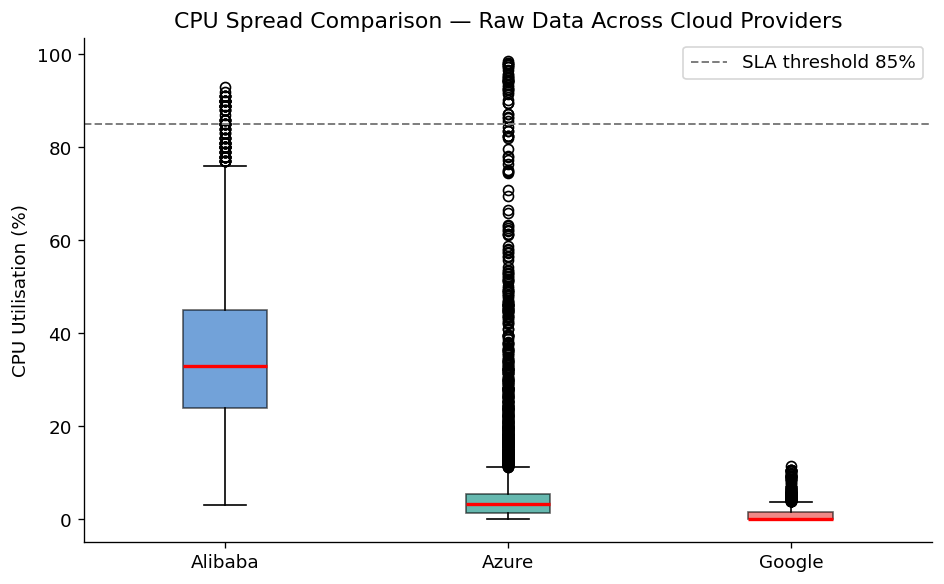


Statistical summary:
  Alibaba   : median=34.0%  std=17.4  P95=62.0%  P99=83.0%
  Azure     : median=3.3%  std=11.7  P95=24.3%  P99=72.0%
  Google    : median=0.0%  std=1.4  P95=2.8%  P99=6.2%


In [166]:
# ── 3.3  Cross-provider box plot comparison ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
plot_data   = [s.sample(min(5000, len(s)), random_state=42).values
               for s in datasets_raw.values()]
plot_labels = list(datasets_raw.keys())

bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True,
                medianprops={'color': 'red', 'linewidth': 2})
palette = ['#1565C0', '#00897B', '#E53935']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.6)

ax.axhline(85, color='grey', linestyle='--', lw=1.2, label='SLA threshold 85%')
ax.set_ylabel('CPU Utilisation (%)')
ax.set_title('CPU Spread Comparison — Raw Data Across Cloud Providers')
ax.legend()
plt.tight_layout()
plt.savefig('data/Graph/eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStatistical summary:')
for name, series in datasets_raw.items():
    print(f'  {name:<10}: median={series.median():.1f}%  std={series.std():.1f}  '
          f'P95={series.quantile(0.95):.1f}%  P99={series.quantile(0.99):.1f}%')

### 3.4 Node-level heterogeneity (Alibaba top-20 machines)

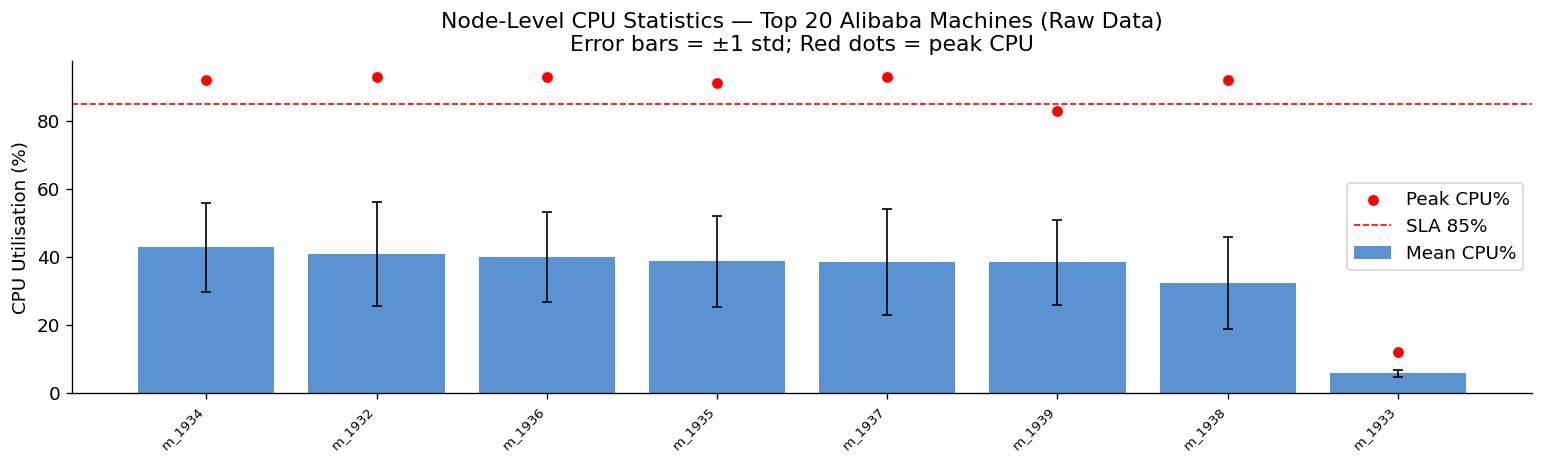


Node variance observation: std of per-node means = 12.07% — high heterogeneity motivates per-node feature engineering


In [167]:
# ── 3.4  Node-level heterogeneity (Alibaba top-20 machines) ───────────────────
if ali_raw is not None:
    cpu_col  = next((c for c in ali_raw.columns if 'cpu' in c.lower()), ali_raw.columns[2])
    node_col = ali_raw.columns[0]
    ali_raw[cpu_col] = pd.to_numeric(ali_raw[cpu_col], errors='coerce')

    node_stats = (ali_raw.groupby(node_col)[cpu_col]
                  .agg(['mean','std','max'])
                  .rename(columns={'mean':'Mean CPU','std':'Std','max':'Peak CPU'})
                  .sort_values('Mean CPU', ascending=False)
                  .head(20))

    fig, ax = plt.subplots(figsize=(13, 4))
    x = range(len(node_stats))
    ax.bar(x, node_stats['Mean CPU'], color='#1565C0', alpha=0.7, label='Mean CPU%')
    ax.errorbar(x, node_stats['Mean CPU'], yerr=node_stats['Std'],
                fmt='none', color='black', capsize=3, lw=1)
    ax.scatter(x, node_stats['Peak CPU'], color='red', s=30, zorder=5, label='Peak CPU%')
    ax.axhline(85, color='red', linestyle='--', lw=1, label='SLA 85%')
    ax.set_xticks(list(x))
    ax.set_xticklabels(node_stats.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('CPU Utilisation (%)')
    ax.set_title('Node-Level CPU Statistics — Top 20 Alibaba Machines (Raw Data)\n'
                 'Error bars = ±1 std; Red dots = peak CPU')
    ax.legend()
    plt.tight_layout()
    plt.savefig('data/Graph/eda_node_variance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nNode variance observation: std of per-node means = '
          f"{node_stats['Mean CPU'].std():.2f}% — high heterogeneity motivates per-node feature engineering")

---
## Section 4 — Data Cleaning & Preprocessing


### 4.1 Preprocessing functions (defined inline)

In [168]:
# ── 4.1  Preprocessing functions (defined inline) ─────────────────────────────
from sklearn.preprocessing import MinMaxScaler

# Constants for feature engineering
ALIBABA_ROWS = 500000
AZURE_ROWS = 200000
GOOGLE_ROWS = 150000
WINDOW_SIZE  = 6
LAG_STEPS    = [1, 3, 6, 18, 36, 144]
ROLLING_WINS = [3, 6, 18, 36]

def column_missing_summary(df, name, stage=''):
    summary = pd.DataFrame({
        'column': df.columns,
        'null_count': df.isnull().sum().values,
        'null_pct': (df.isnull().mean().values * 100).round(2),
        'dtype': [str(t) for t in df.dtypes],
    })
    summary = summary.sort_values(['null_count', 'column'], ascending=[False, True]).reset_index(drop=True)
    title = f"{name} - missing/null values"
    if stage:
        title += f" {stage}"
    print(f"\n{title}")
    display(summary)

def load_alibaba(sample_machines=80, nrows=ALIBABA_ROWS):
    path = Path('data/raw/alibaba/machine_usage.csv')
    print(f'Loading Alibaba from {path}...')
    df = pd.read_csv(path, header=None, nrows=nrows)
    df.columns = ['node_id','ts','cpu','mem',
                  'mem_gps','mkpi','net_in','net_out','disk_io'][:len(df.columns)]
    df = df[['node_id','ts','cpu','mem']].copy()
    machines = df['node_id'].unique()
    if len(machines) > sample_machines:
        machines = np.random.choice(machines, sample_machines, replace=False)
        df = df[df['node_id'].isin(machines)]
    df['provider'] = 'alibaba'
    df['cpu'] = pd.to_numeric(df['cpu'], errors='coerce')
    df['mem'] = pd.to_numeric(df['mem'], errors='coerce')
    print(f'  → {len(df):,} rows, {df["node_id"].nunique()} nodes')
    return df

def load_azure(nrows=AZURE_ROWS):
    path = Path('data/raw/azure/vm_cpu_readings.csv')
    gz   = Path('data/raw/azure/vm_cpu_readings.csv.gz')
    if path.exists():
        print(f'Loading Azure from {path}...')
        df = pd.read_csv(path, header=None, nrows=nrows,
                         names=['ts','node_id','cpu_min','cpu_max','cpu'])
    elif gz.exists():
        print(f'Loading Azure from {gz}...')
        df = pd.read_csv(gz, compression='gzip', header=None, nrows=nrows,
                         names=['ts','node_id','cpu_min','cpu_max','cpu'])
    else:
        raise FileNotFoundError('Azure dataset not found')
    available = [c for c in ['node_id','ts','cpu','mem'] if c in df.columns]
    df = df[available].copy()
    if 'mem' not in df.columns:
        df['mem'] = df['cpu'] * 0.75 + np.random.normal(0, 3, len(df))
    df['provider'] = 'azure'
    df['cpu'] = pd.to_numeric(df['cpu'], errors='coerce')
    df['mem'] = pd.to_numeric(df['mem'], errors='coerce')
    print(f'  → {len(df):,} rows, {df["node_id"].nunique()} nodes')
    return df

def load_google(nrows=GOOGLE_ROWS):
    # Google Cluster Traces v3: space/tab-separated task-level data
    path = Path('data/raw/google/google_cluster_data_1.csv')
    print(f'Loading Google from {path}...')
    df = pd.read_csv(path, sep=r'\s+', engine='python', nrows=nrows)
    if len(df.columns) == 1:
        df = pd.read_csv(path, sep=' ', engine='python', skipinitialspace=True, nrows=nrows)
    df = df.rename(columns={'Time':'ts','TaskID':'node_id',
                            'NrmlTaskCores':'cpu','NrmlTaskMem':'mem'})
    keep = [c for c in ['node_id','ts','cpu','mem'] if c in df.columns]
    if 'cpu' not in keep or 'mem' not in keep:
        raise ValueError(
            'Google file could not be mapped to cpu/mem columns. '
            f'Available columns: {list(df.columns)}'
        )
    df = df[keep].copy()
    # Convert normalised fractions (0-1) to percentages
    if df['cpu'].max() <= 1.0:
        df['cpu'] = df['cpu'] * 100
        df['mem'] = df['mem'] * 100
    df['provider'] = 'google'
    df['cpu'] = pd.to_numeric(df['cpu'], errors='coerce')
    df['mem'] = pd.to_numeric(df['mem'], errors='coerce')
    print(f'  → {len(df):,} rows, {df["node_id"].nunique()} nodes')
    return df

def clean(df):
    df = df.dropna(subset=['cpu','mem'])
    df['cpu'] = df['cpu'].clip(0, 100)
    df['mem'] = df['mem'].clip(0, 100)
    for col in ['cpu','mem']:
        p99 = df.groupby('node_id')[col].transform(lambda x: x.quantile(0.99))
        df[col] = df[col].clip(upper=p99)
    df = df.sort_values(['node_id','ts']).reset_index(drop=True)
    return df

print('Preprocessing functions defined (inline)')

Preprocessing functions defined (inline)


### 4.2 Load and standardise schemas

In [169]:
# ── 4.2  Load and standardise schemas ────────────────────────────────────────
# Each loader: renames columns, casts types, samples machines (Alibaba)
ali   = load_alibaba(sample_machines=80)
azure = load_azure()
goog  = load_google()

print('\nAfter schema standardisation (before cleaning):')
print(f'  {"Dataset":<10} {"Rows":>10}  Columns')
for name, df in [('Alibaba', ali), ('Azure', azure), ('Google', goog)]:
    print(f'  {name:<10} {len(df):>10,}  {list(df.columns)}')

Loading Alibaba from data/raw/alibaba/machine_usage.csv...
  → 500,000 rows, 74 nodes
Loading Azure from data/raw/azure/vm_cpu_readings.csv...
  → 200,000 rows, 200000 nodes
Loading Google from data/raw/google/google_cluster_data_1.csv...
  → 150,000 rows, 56560 nodes

After schema standardisation (before cleaning):
  Dataset          Rows  Columns
  Alibaba       500,000  ['node_id', 'ts', 'cpu', 'mem', 'provider']
  Azure         200,000  ['node_id', 'ts', 'cpu', 'mem', 'provider']
  Google        150,000  ['node_id', 'ts', 'cpu', 'mem', 'provider']


### 4.2.1 Missing and null values after schema standardisation

This subsection shows per-column missing and null counts for the standardised datasets before any cleaning is applied.


In [170]:
# ── 4.2.1  Missing and null values after schema standardisation ─────────────
for name, df in [('Alibaba', ali), ('Azure', azure), ('Google', goog)]:
    column_missing_summary(df, name, stage='after schema standardisation')



Alibaba - missing/null values after schema standardisation


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,int64
1,mem,0,0.0000,int64
2,node_id,0,0.0000,object
3,provider,0,0.0000,object
4,ts,0,0.0000,int64



Azure - missing/null values after schema standardisation


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,float64
1,mem,0,0.0000,float64
2,node_id,0,0.0000,object
3,provider,0,0.0000,object
4,ts,0,0.0000,int64



Google - missing/null values after schema standardisation


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,float64
1,mem,0,0.0000,float64
2,node_id,0,0.0000,int64
3,provider,0,0.0000,object
4,ts,0,0.0000,int64


### 4.3 RAW (standardised but NOT yet cleaned)

In [171]:
# ── 4.3  RAW (standardised but NOT yet cleaned) ───────────────────────────────
print('══════════ BEFORE CLEANING — Alibaba (standardised schema) ══════════')
print(f'Shape: {ali.shape}')
display(ali.head(5))

print('\n── Missing values (BEFORE clean) ──')
display(ali[['cpu','mem']].isnull().sum().to_frame('nulls').T)

print('\n── CPU statistics (BEFORE winsorisation) ──')
display(ali[['cpu','mem']].describe().round(2))

══════════ BEFORE CLEANING — Alibaba (standardised schema) ══════════
Shape: (500000, 5)


,node_id,ts,cpu,mem,provider
0,m_1932,386640,41,92,alibaba
1,m_1932,386670,43,92,alibaba
2,m_1932,386690,44,92,alibaba
3,m_1932,386800,46,92,alibaba
4,m_1932,386930,44,93,alibaba



── Missing values (BEFORE clean) ──


,cpu,mem
nulls,0,0



── CPU statistics (BEFORE winsorisation) ──


,cpu,mem
count,500000.0000,500000.0000
mean,35.2800,84.3300
std,17.8000,21.8900
min,0.0000,1.0000
25%,25.0000,87.0000
50%,36.0000,91.0000
75%,47.0000,93.0000
max,98.0000,98.0000


### 4.4 Apply cleaning

In [172]:
# ── 4.4  Apply cleaning ────────────────────────────────────────────────────────
ali_before_rows = len(ali)
ali   = clean(ali)
azure = clean(azure)
goog  = clean(goog)

print('──── Cleaning results ────')
for name, df in [('Alibaba', ali), ('Azure', azure), ('Google', goog)]:
    print(f'  {name:<10}: {len(df):,} rows | '
          f'cpu range [{df["cpu"].min():.1f}, {df["cpu"].max():.1f}] | '
          f'nulls: {df[["cpu","mem"]].isnull().sum().sum()}')

──── Cleaning results ────
  Alibaba   : 500,000 rows | cpu range [0.0, 95.0] | nulls: 0
  Azure     : 200,000 rows | cpu range [0.0, 99.5] | nulls: 0
  Google    : 150,000 rows | cpu range [0.0, 12.5] | nulls: 0


### 4.5 PROCESSED (cleaned) data sample

In [173]:
# ── 4.5  PROCESSED (cleaned) data sample ─────────────────────────────────────
print('══════════ AFTER CLEANING — Alibaba ══════════')
print(f'Shape: {ali.shape}')
display(ali.head(5))

print('\n── Statistics (AFTER winsorisation) ──')
display(ali[['cpu','mem']].describe().round(2))

══════════ AFTER CLEANING — Alibaba ══════════
Shape: (500000, 5)


,node_id,ts,cpu,mem,provider
0,m_1932,386640,41.0000,92,alibaba
1,m_1932,386670,43.0000,92,alibaba
2,m_1932,386690,44.0000,92,alibaba
3,m_1932,386800,46.0000,92,alibaba
4,m_1932,386930,44.0000,93,alibaba



── Statistics (AFTER winsorisation) ──


,cpu,mem
count,500000.0000,500000.0000
mean,35.2500,84.3300
std,17.7100,21.8900
min,0.0000,1.0000
25%,25.0000,87.0000
50%,36.0000,91.0000
75%,47.0000,93.0000
max,95.0000,97.0000


### 4.5.1 Missing and null values after cleaning

This subsection confirms the per-column missing and null counts after the cleaning pipeline has been applied.


In [174]:
# ── 4.5.1  Missing and null values after cleaning ───────────────────────────
for name, df in [('Alibaba', ali), ('Azure', azure), ('Google', goog)]:
    column_missing_summary(df, name, stage='after cleaning')



Alibaba - missing/null values after cleaning


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,float64
1,mem,0,0.0000,int64
2,node_id,0,0.0000,object
3,provider,0,0.0000,object
4,ts,0,0.0000,int64



Azure - missing/null values after cleaning


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,float64
1,mem,0,0.0000,float64
2,node_id,0,0.0000,object
3,provider,0,0.0000,object
4,ts,0,0.0000,int64



Google - missing/null values after cleaning


,column,null_count,null_pct,dtype
0,cpu,0,0.0000,float64
1,mem,0,0.0000,float64
2,node_id,0,0.0000,int64
3,provider,0,0.0000,object
4,ts,0,0.0000,int64


### 4.6 Before vs After — visual comparison

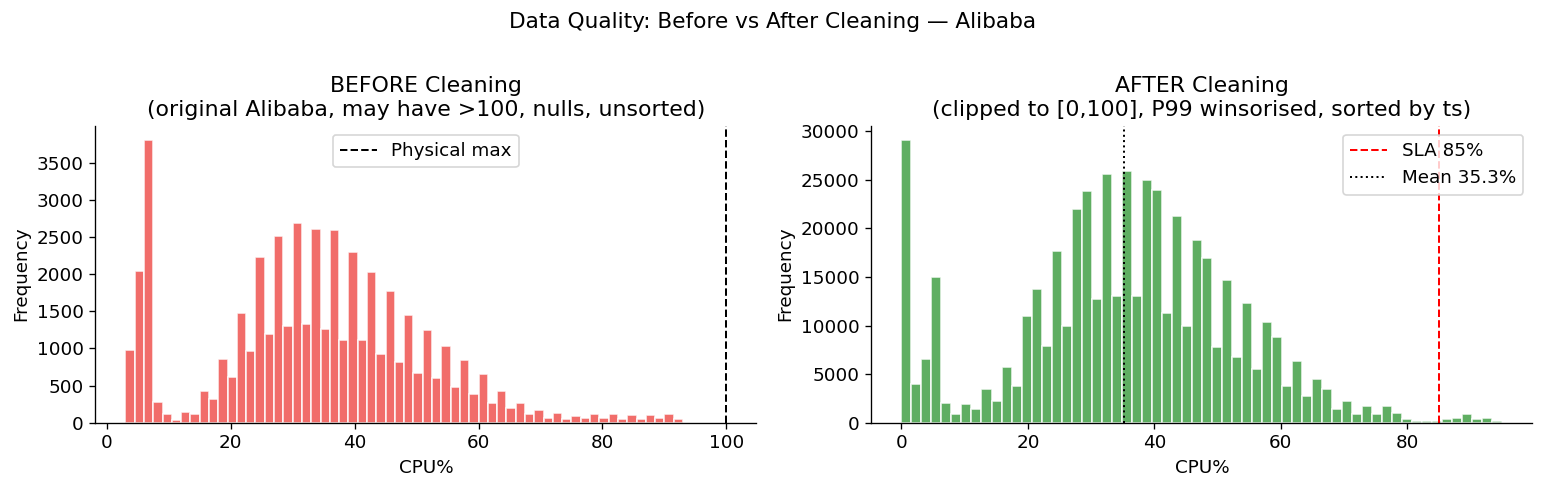

Rows removed by cleaning: 0


In [175]:
# ── 4.6  Before vs After — visual comparison ──────────────────────────────────
if ali_raw is not None:
    cpu_col_raw = next((c for c in ali_raw.columns if 'cpu' in c.lower()), ali_raw.columns[2])
    raw_cpu   = pd.to_numeric(ali_raw[cpu_col_raw], errors='coerce').dropna()
    clean_cpu = ali['cpu']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(raw_cpu.clip(0, 120), bins=60, color='#EF5350', alpha=0.85, edgecolor='white')
    axes[0].axvline(100, color='black', lw=1.2, linestyle='--', label='Physical max')
    axes[0].set_title('BEFORE Cleaning\n(original Alibaba, may have >100, nulls, unsorted)')
    axes[0].set_xlabel('CPU%'); axes[0].set_ylabel('Frequency'); axes[0].legend()

    axes[1].hist(clean_cpu, bins=60, color='#43A047', alpha=0.85, edgecolor='white')
    axes[1].axvline(85, color='red', lw=1.2, linestyle='--', label='SLA 85%')
    axes[1].axvline(clean_cpu.mean(), color='black', lw=1.2, linestyle=':',
                    label=f'Mean {clean_cpu.mean():.1f}%')
    axes[1].set_title('AFTER Cleaning\n(clipped to [0,100], P99 winsorised, sorted by ts)')
    axes[1].set_xlabel('CPU%'); axes[1].set_ylabel('Frequency'); axes[1].legend()

    plt.suptitle('Data Quality: Before vs After Cleaning — Alibaba', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('data/Graph/cleaning_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Rows removed by cleaning: {ali_before_rows - len(ali):,}')

---
## Section 5 — Feature Engineering

The cleaned time-series now contains the standardised core signals `[node_id, ts, cpu, mem]`. To support dual-target forecasting, the notebook engineers variables for both future CPU and future memory utilisation.


### 5.1 Engineer features for all datasets

In [176]:
# -- 5.1 Engineer features for all datasets ----------------------------------

def get_feature_cols(df):
    exclude = {
        'node_id', 'ts', 'provider',
        'target_cpu_h1', 'target_cpu', 'target_cpu_h6',
        'target_mem_h1', 'target_mem', 'target_mem_h6',
        'sla_breach'
    }
    return [c for c in df.columns if c not in exclude]


def _build_features_for_group(grp, target_horizon):
    feat = pd.DataFrame()
    feat['node_id'] = grp['node_id']
    feat['ts'] = grp['ts']
    feat['provider'] = grp['provider']
    feat['cpu'] = grp['cpu']
    feat['mem'] = grp['mem']

    feat['target_cpu_h1'] = grp['cpu'].shift(-1)
    feat['target_cpu'] = grp['cpu'].shift(-3)
    feat['target_cpu_h6'] = grp['cpu'].shift(-6)
    feat['target_mem_h1'] = grp['mem'].shift(-1)
    feat['target_mem'] = grp['mem'].shift(-3)
    feat['target_mem_h6'] = grp['mem'].shift(-6)

    for lag in LAG_STEPS:
        feat[f'cpu_lag_{lag}'] = grp['cpu'].shift(lag)
        feat[f'mem_lag_{lag}'] = grp['mem'].shift(lag)

    for win in ROLLING_WINS:
        feat[f'cpu_roll_mean_{win}'] = grp['cpu'].rolling(win).mean()
        feat[f'cpu_roll_std_{win}'] = grp['cpu'].rolling(win).std()
        feat[f'cpu_roll_max_{win}'] = grp['cpu'].rolling(win).max()
        feat[f'cpu_roll_min_{win}'] = grp['cpu'].rolling(win).min()
        feat[f'mem_roll_mean_{win}'] = grp['mem'].rolling(win).mean()
        feat[f'mem_roll_std_{win}'] = grp['mem'].rolling(win).std()
        feat[f'mem_roll_max_{win}'] = grp['mem'].rolling(win).max()
        feat[f'mem_roll_min_{win}'] = grp['mem'].rolling(win).min()

    feat['cpu_roc_1'] = grp['cpu'].diff(1)
    feat['cpu_roc_6'] = grp['cpu'].diff(6)
    feat['cpu_roc_18'] = grp['cpu'].diff(18)
    feat['mem_roc_1'] = grp['mem'].diff(1)
    feat['mem_roc_6'] = grp['mem'].diff(6)
    feat['mem_roc_18'] = grp['mem'].diff(18)

    ts_hours = (grp['ts'] % 86400) / 3600
    feat['hour_sin'] = np.sin(2 * np.pi * ts_hours / 24)
    feat['hour_cos'] = np.cos(2 * np.pi * ts_hours / 24)
    ts_days = (grp['ts'] // 86400) % 7
    feat['dow_sin'] = np.sin(2 * np.pi * ts_days / 7)
    feat['dow_cos'] = np.cos(2 * np.pi * ts_days / 7)

    feat['cpu_mem_ratio'] = grp['cpu'] / (grp['mem'] + 1e-6)
    feat['mem_cpu_gap'] = grp['mem'] - grp['cpu']
    feat['sla_breach'] = (grp['cpu'].shift(-target_horizon) > 85).astype(int)
    return feat


def engineer_features(df, target_horizon=3):
    min_len = max(LAG_STEPS) + 6 + 10
    all_node_dfs = []
    for node_id, grp in df.groupby('node_id'):
        grp = grp.sort_values('ts').reset_index(drop=True)
        if len(grp) < min_len:
            continue
        all_node_dfs.append(_build_features_for_group(grp, target_horizon))

    if not all_node_dfs:
        provider = str(df['provider'].iloc[0]) if ('provider' in df.columns and len(df)) else 'unknown'
        required = {'ts', 'cpu', 'mem'}
        if required.issubset(df.columns):
            seq = df[['cpu', 'mem']].copy().reset_index(drop=True)
            seq = seq.dropna(subset=['cpu', 'mem'])
            if len(seq) >= min_len:
                seq['ts'] = np.arange(len(seq), dtype=np.int64)
                seq['node_id'] = f'{provider}_global'
                seq['provider'] = provider
                seq = seq[['node_id', 'ts', 'provider', 'cpu', 'mem']]
                all_node_dfs.append(_build_features_for_group(seq, target_horizon))
                print(f'  -> {provider}: using sequential provider-level fallback series for features')

    if not all_node_dfs:
        return pd.DataFrame()

    return pd.concat(all_node_dfs, ignore_index=True).dropna()


print('Engineering features for CPU and memory forecasting...')
ali_feat = engineer_features(ali)
azure_feat = engineer_features(azure)
goog_feat = engineer_features(goog)

print(f"\n{'Dataset':<12} {'Raw Rows':>10}  {'Feature Rows':>14}  {'Feature Cols':>14}")
print('-' * 58)
for name, raw_df, feat_df in [('Alibaba', ali, ali_feat), ('Azure', azure, azure_feat), ('Google', goog, goog_feat)]:
    fcols = get_feature_cols(feat_df)
    print(f"{name:<12} {len(raw_df):>10,}  {len(feat_df):>14,}  {len(fcols):>14}")
print('(Rows reduce because lagged predictors and future targets require full history.)')


Engineering features for CPU and memory forecasting...
  -> azure: using sequential provider-level fallback series for features
  -> google: using sequential provider-level fallback series for features

Dataset        Raw Rows    Feature Rows    Feature Cols
----------------------------------------------------------
Alibaba         500,000         488,900              58
Azure           200,000         199,850              58
Google          150,000         149,850              58
(Rows reduce because lagged predictors and future targets require full history.)


### 5.2 Before vs After Feature Engineering

In [177]:
# ── 5.2  Before vs After Feature Engineering ─────────────────────────────────
print('══════════ BEFORE Feature Engineering ══════════')
display(ali.head(5)[['node_id','ts','cpu','mem']])

print('\n══════════ AFTER Feature Engineering — sample columns ══════════')
show_cols = ['node_id','ts','cpu','mem',
             'cpu_lag_1','cpu_lag_3','cpu_lag_6',
             'cpu_roll_mean_3','cpu_roll_std_3',
             'cpu_roc_1','hour_sin','hour_cos',
             'target_cpu']
available = [c for c in show_cols if c in ali_feat.columns]
display(ali_feat[available].head(5))

print(f'\nTotal features created: {len(get_feature_cols(ali_feat))}')
feat_cols = get_feature_cols(ali_feat)
cats = {
    'Lag (cpu)':     [c for c in feat_cols if 'cpu_lag' in c],
    'Lag (mem)':     [c for c in feat_cols if 'mem_lag' in c],
    'Rolling mean':  [c for c in feat_cols if 'roll_mean' in c],
    'Rolling std':   [c for c in feat_cols if 'roll_std' in c],
    'Rate-of-change':[c for c in feat_cols if 'roc' in c],
    'Temporal':      [c for c in feat_cols if any(t in c for t in ('sin','cos'))],
    'Other':         [c for c in feat_cols if not any(k in c for k in ('lag','roll','roc','sin','cos'))],
}
for cat, cols in cats.items():
    if cols:
        print(f'  {cat:<18}: {len(cols):>3}  {cols[:4]}...' if len(cols)>4 else f'  {cat:<18}: {cols}')

══════════ BEFORE Feature Engineering ══════════


,node_id,ts,cpu,mem
0,m_1932,386640,41.0000,92
1,m_1932,386670,43.0000,92
2,m_1932,386690,44.0000,92
3,m_1932,386800,46.0000,92
4,m_1932,386930,44.0000,93



══════════ AFTER Feature Engineering — sample columns ══════════


,node_id,ts,cpu,mem,cpu_lag_1,cpu_lag_3,cpu_lag_6,cpu_roll_mean_3,cpu_roll_std_3,cpu_roc_1,hour_sin,hour_cos,target_cpu
144,m_1932,398980,34.0000,92,33.0000,41.0000,40.0000,37.3333,6.6583,1.0000,-0.6745,-0.7383,37.0000
145,m_1932,399110,38.0000,95,34.0000,45.0000,52.0000,35.0000,2.6458,4.0000,-0.6815,-0.7318,28.0000
146,m_1932,399320,44.0000,97,38.0000,33.0000,37.0000,38.6667,5.0332,6.0000,-0.6926,-0.7214,42.0000
147,m_1932,399460,37.0000,95,44.0000,34.0000,41.0000,39.6667,3.7859,-7.0000,-0.6999,-0.7143,48.0000
148,m_1932,399590,28.0000,93,37.0000,38.0000,45.0000,36.3333,8.0208,-9.0000,-0.7066,-0.7076,35.0000



Total features created: 58
  Lag (cpu)         :   6  ['cpu_lag_1', 'cpu_lag_3', 'cpu_lag_6', 'cpu_lag_18']...
  Lag (mem)         :   6  ['mem_lag_1', 'mem_lag_3', 'mem_lag_6', 'mem_lag_18']...
  Rolling mean      :   8  ['cpu_roll_mean_3', 'mem_roll_mean_3', 'cpu_roll_mean_6', 'mem_roll_mean_6']...
  Rolling std       :   8  ['cpu_roll_std_3', 'mem_roll_std_3', 'cpu_roll_std_6', 'mem_roll_std_6']...
  Rate-of-change    :   6  ['cpu_roc_1', 'cpu_roc_6', 'cpu_roc_18', 'mem_roc_1']...
  Temporal          : ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  Other             : ['cpu', 'mem', 'cpu_mem_ratio', 'mem_cpu_gap']


### 5.3 Top features correlated with 30-min forecast target

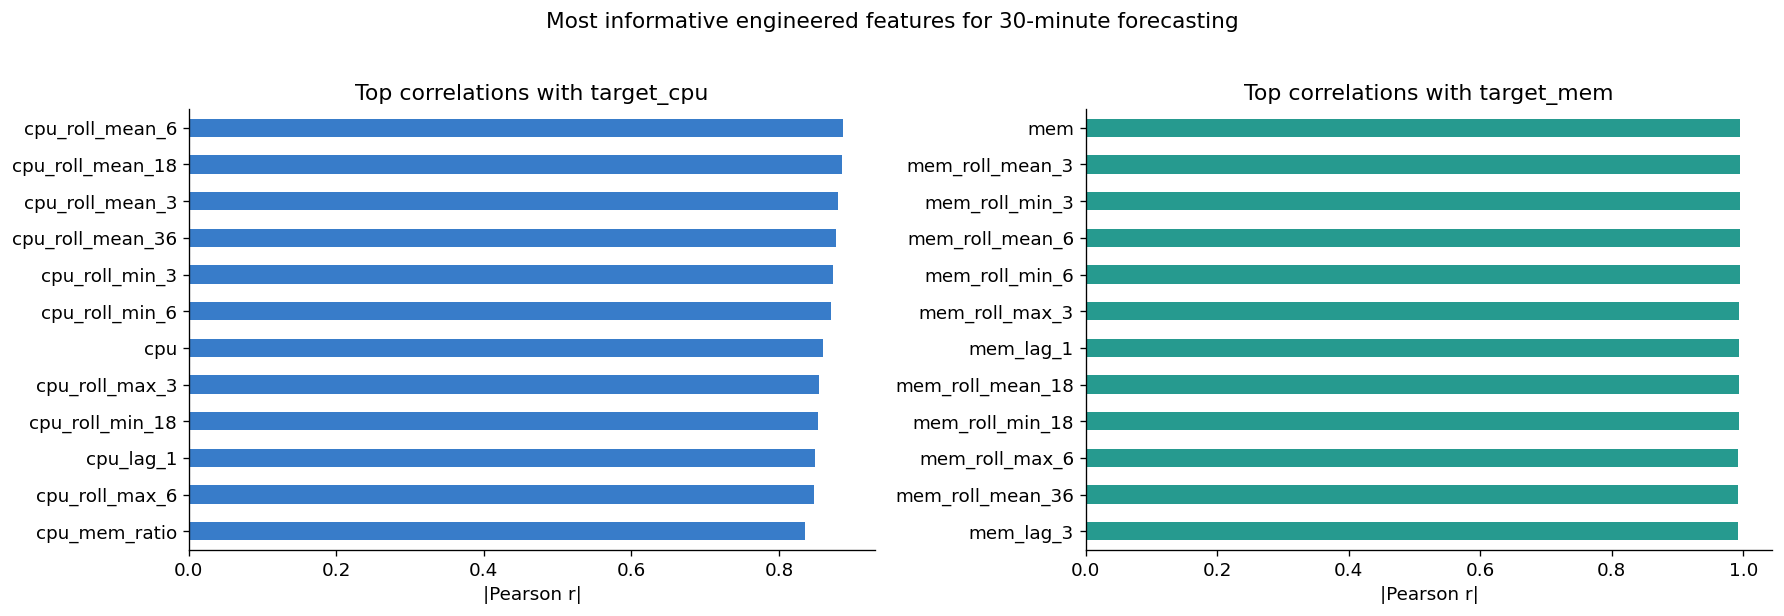

Top CPU predictors:
  cpu_roll_mean_6                     r=0.8865
  cpu_roll_mean_18                    r=0.8851
  cpu_roll_mean_3                     r=0.8806
  cpu_roll_mean_36                    r=0.8778
  cpu_roll_min_3                      r=0.8732

Top memory predictors:
  mem                                 r=0.9946
  mem_roll_mean_3                     r=0.9946
  mem_roll_min_3                      r=0.9944
  mem_roll_mean_6                     r=0.9943
  mem_roll_min_6                      r=0.9943


In [178]:
# -- 5.3 Top features correlated with 30-minute forecast targets --------------
feat_cols = get_feature_cols(ali_feat)

top_corr_cpu = (
    ali_feat[feat_cols + ['target_cpu']]
    .corr()['target_cpu']
    .abs()
    .sort_values(ascending=False)
    .drop('target_cpu')
    .head(12)
)

top_corr_mem = (
    ali_feat[feat_cols + ['target_mem']]
    .corr()['target_mem']
    .abs()
    .sort_values(ascending=False)
    .drop('target_mem')
    .head(12)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_corr_cpu.sort_values().plot(kind='barh', ax=axes[0], color='#1565C0', alpha=0.85)
top_corr_mem.sort_values().plot(kind='barh', ax=axes[1], color='#00897B', alpha=0.85)
axes[0].set_title('Top correlations with target_cpu')
axes[1].set_title('Top correlations with target_mem')
axes[0].set_xlabel('|Pearson r|')
axes[1].set_xlabel('|Pearson r|')
plt.suptitle('Most informative engineered features for 30-minute forecasting', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/Graph/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top CPU predictors:')
for f, r in top_corr_cpu.head(5).items():
    print(f'  {f:<35} r={r:.4f}')

print('\nTop memory predictors:')
for f, r in top_corr_mem.head(5).items():
    print(f'  {f:<35} r={r:.4f}')


---
## Section 6 — Feature Selection

Feature selection is now performed separately for CPU and memory forecasting. This keeps the comparison fair and recognises that the strongest predictors for future CPU are not always identical to the strongest predictors for future memory usage.


### 6.1 Two-stage feature selection

In [179]:
# -- 6.1 Two-stage feature selection -----------------------------------------
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor


def correlation_filter(df, feature_cols, threshold=0.95):
    X = df[feature_cols]
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    surviving = [c for c in feature_cols if c not in to_drop]
    print(f'  Correlation filter: {len(feature_cols)} -> {len(surviving)} features (dropped {len(to_drop)})')
    return surviving


def rfe_selection(df, feature_cols, target_col, n_features=25):
    n_select = min(n_features, len(feature_cols))
    X = df[feature_cols].values
    y = df[target_col].values
    estimator = XGBRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, tree_method='hist', random_state=42, n_jobs=1, verbosity=0
    )
    rfe = RFE(estimator=estimator, n_features_to_select=n_select, step=3)
    rfe.fit(X, y)
    selected = [col for col, support in zip(feature_cols, rfe.support_) if support]
    print(f'  RFE for {target_col}: {len(feature_cols)} -> {len(selected)} selected')
    return selected, rfe.ranking_


feat_cols = get_feature_cols(ali_feat)
after_corr = correlation_filter(ali_feat, feat_cols, threshold=0.95)
selected_features_cpu, rfe_ranking_cpu = rfe_selection(ali_feat, after_corr, 'target_cpu', n_features=25)
selected_features_mem, rfe_ranking_mem = rfe_selection(ali_feat, after_corr, 'target_mem', n_features=25)

selected_features_map = {
    'cpu': selected_features_cpu,
    'memory': selected_features_mem,
}

print('\nFeature selection summary:')
print(f'  Original predictors      : {len(feat_cols)}')
print(f'  After correlation filter : {len(after_corr)}')
print(f'  CPU selected             : {len(selected_features_cpu)}')
print(f'  Memory selected          : {len(selected_features_mem)}')
print(f'  Shared selected          : {len(set(selected_features_cpu) & set(selected_features_mem))}')

joblib.dump(selected_features_cpu, 'data/processed/alibaba_selected_features_cpu.pkl')
joblib.dump(selected_features_mem, 'data/processed/alibaba_selected_features_mem.pkl')
joblib.dump(rfe_ranking_cpu, 'data/processed/alibaba_rfe_importances_cpu.pkl')
joblib.dump(rfe_ranking_mem, 'data/processed/alibaba_rfe_importances_mem.pkl')


  Correlation filter: 58 -> 28 features (dropped 30)
  RFE for target_cpu: 28 -> 25 selected
  RFE for target_mem: 28 -> 25 selected

Feature selection summary:
  Original predictors      : 58
  After correlation filter : 28
  CPU selected             : 25
  Memory selected          : 25
  Shared selected          : 22


['data/processed/alibaba_rfe_importances_mem.pkl']

### 6.2 RFE ranking visualisation

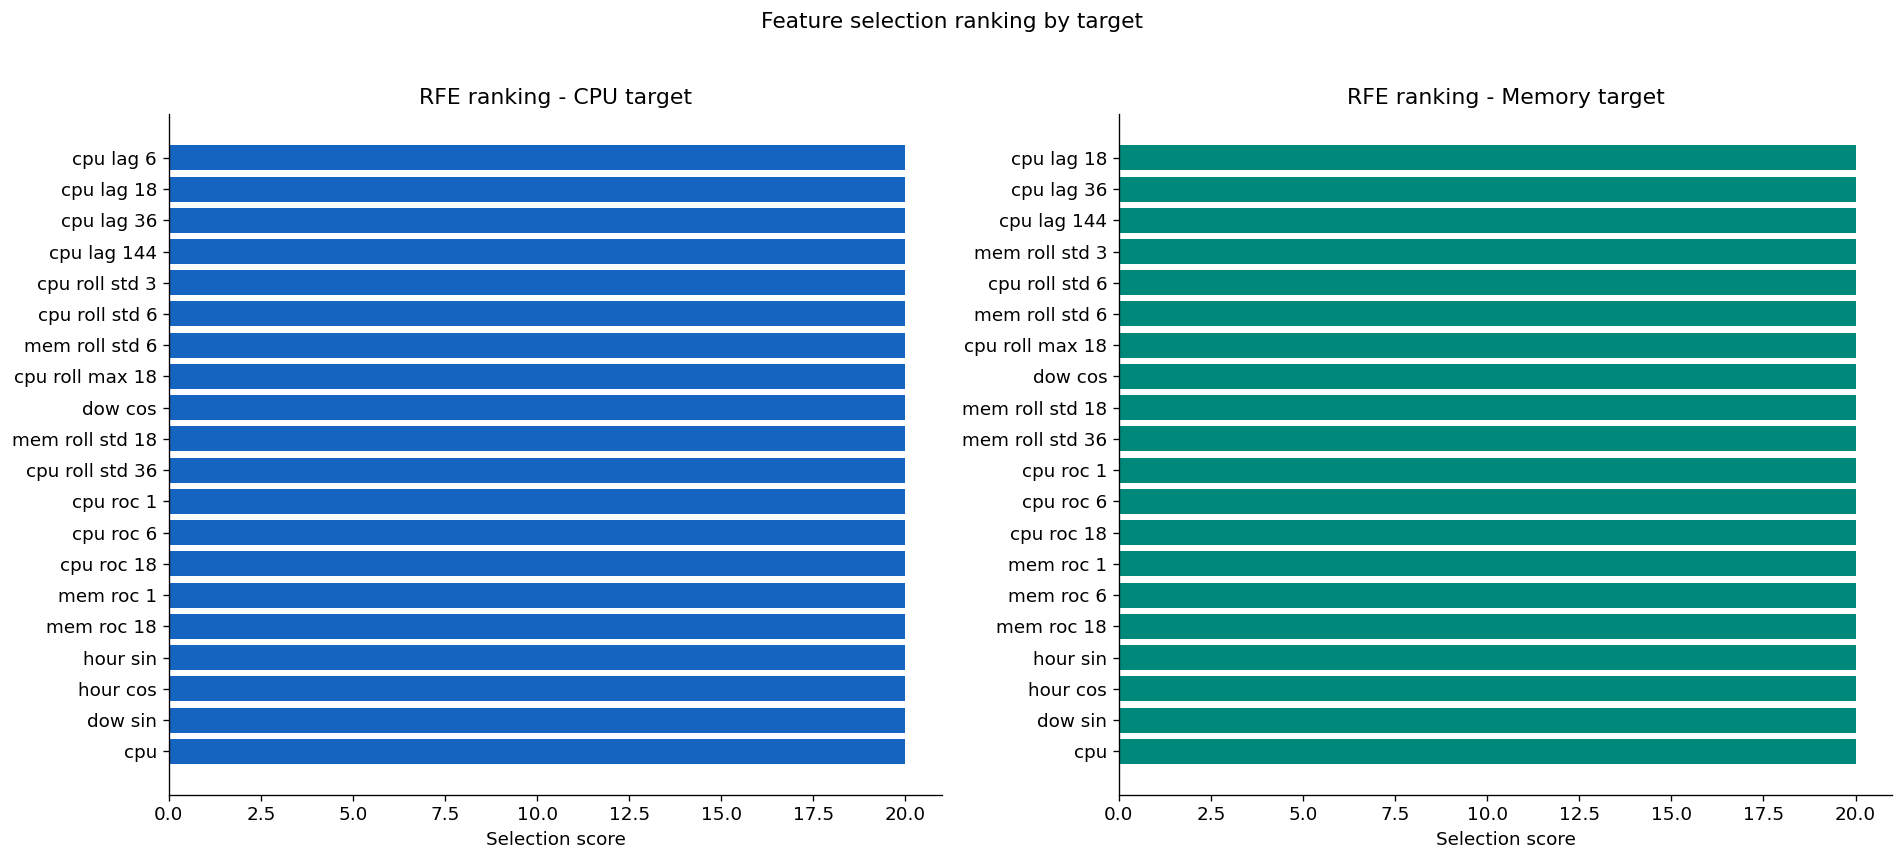

In [180]:
# -- 6.2 RFE ranking visualisation -------------------------------------------
rank_df_cpu = pd.DataFrame({'feature': after_corr, 'rank': rfe_ranking_cpu}).sort_values('rank').head(20)
rank_df_mem = pd.DataFrame({'feature': after_corr, 'rank': rfe_ranking_mem}).sort_values('rank').head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(rank_df_cpu['feature'].str.replace('_', ' '), 21 - rank_df_cpu['rank'], color='#1565C0')
axes[1].barh(rank_df_mem['feature'].str.replace('_', ' '), 21 - rank_df_mem['rank'], color='#00897B')
axes[0].set_title('RFE ranking - CPU target')
axes[1].set_title('RFE ranking - Memory target')
axes[0].set_xlabel('Selection score')
axes[1].set_xlabel('Selection score')
plt.suptitle('Feature selection ranking by target', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/Graph/rfe_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 7 — Train / Validation / Test Split

The split remains strictly temporal to avoid leakage. The same processed data splits are then reused for both CPU and memory targets, which keeps the experimental design reproducible and comparable.


### 7.1 Temporal split and normalisation for all providers

In [181]:
# ── 7.1  Temporal split and normalisation for all providers ───────────────────

def temporal_split(df, train_frac=0.70, val_frac=0.15):
    if df.empty or 'node_id' not in df.columns:
        empty = df.iloc[0:0].copy()
        return empty, empty.copy(), empty.copy()

    train_parts, val_parts, test_parts = [], [], []
    for node_id, grp in df.groupby('node_id'):
        grp = grp.sort_values('ts').reset_index(drop=True)
        n = len(grp)
        t1 = int(n * train_frac)
        t2 = int(n * (train_frac + val_frac))
        train_parts.append(grp.iloc[:t1])
        val_parts.append(grp.iloc[t1:t2])
        test_parts.append(grp.iloc[t2:])

    if not train_parts:
        empty = df.iloc[0:0].copy()
        return empty, empty.copy(), empty.copy()
    return (pd.concat(train_parts, ignore_index=True),
            pd.concat(val_parts, ignore_index=True),
            pd.concat(test_parts, ignore_index=True))

def normalise(train_df, val_df, test_df, feature_cols):
    scaler = MinMaxScaler()
    train_df = train_df.copy()
    val_df   = val_df.copy()
    test_df  = test_df.copy()
    if train_df.empty or len(feature_cols) == 0:
        return train_df, val_df, test_df, None
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, val_df, test_df, scaler

out_dir = Path('data/processed')
print(f'  {"Dataset":<10}  {"Total":>9}  {"Train":>9}  {"Val":>7}  {"Test":>7}')
print('  ' + '-' * 48)

for name, feat_df in [('alibaba', ali_feat),
                       ('azure',   azure_feat),
                       ('google',  goog_feat)]:
    fcols = get_feature_cols(feat_df)
    if feat_df.empty or 'node_id' not in feat_df.columns:
        empty = feat_df.iloc[0:0].copy()
        empty.to_csv(out_dir / f'{name}_train.csv', index=False)
        empty.to_csv(out_dir / f'{name}_val.csv', index=False)
        empty.to_csv(out_dir / f'{name}_test.csv', index=False)
        joblib.dump(None, out_dir / f'{name}_scaler.pkl')
        joblib.dump(fcols, out_dir / f'{name}_feature_cols.pkl')
        print(f'  {name:<10}  {0:>9,}  {0:>9,}  {0:>7,}  {0:>7,}   (no engineered rows)')
        continue
    train, val, test = temporal_split(feat_df, train_frac=0.70, val_frac=0.15)
    train, val, test, scaler = normalise(train, val, test, fcols)
    train.to_csv(out_dir / f'{name}_train.csv', index=False)
    val.to_csv(  out_dir / f'{name}_val.csv',   index=False)
    test.to_csv( out_dir / f'{name}_test.csv',  index=False)
    joblib.dump(scaler, out_dir / f'{name}_scaler.pkl')
    joblib.dump(fcols,  out_dir / f'{name}_feature_cols.pkl')
    total = len(train)+len(val)+len(test)
    print(f'  {name:<10}  {total:>9,}  {len(train):>9,}  {len(val):>7,}  {len(test):>7,}')

print('\n✅ All splits saved to data/processed/')

  Dataset         Total      Train      Val     Test
  ------------------------------------------------
  alibaba       488,900    342,197   73,332   73,371
  azure         199,850    139,895   29,977   29,978
  google        149,850    104,895   22,477   22,478

✅ All splits saved to data/processed/


### 7.2 Verify temporal integrity (no leakage)

In [182]:
# -- 7.2 Verify temporal integrity (no leakage) -------------------------------
train_df = pd.read_csv('data/processed/alibaba_train.csv')
val_df = pd.read_csv('data/processed/alibaba_val.csv')
test_df = pd.read_csv('data/processed/alibaba_test.csv')

print('Temporal integrity check - Alibaba:')
print(f'  Train ts: {train_df["ts"].min():.0f} -> {train_df["ts"].max():.0f}')
print(f'  Val   ts: {val_df["ts"].min():.0f} -> {val_df["ts"].max():.0f}')
print(f'  Test  ts: {test_df["ts"].min():.0f} -> {test_df["ts"].max():.0f}')

print('\nProcessed training sample with both targets:')
fcols_ali = joblib.load('data/processed/alibaba_feature_cols.pkl')
display(train_df[fcols_ali[:6] + ['target_cpu', 'target_mem']].head(5))


Temporal integrity check - Alibaba:
  Train ts: 11850 -> 599720
  Val   ts: 449730 -> 644980
  Test  ts: 529100 -> 690980

Processed training sample with both targets:


,cpu,mem,cpu_lag_1,mem_lag_1,cpu_lag_3,mem_lag_3,target_cpu,target_mem
0,0.3617,0.9474,0.3511,0.9579,0.4362,0.9474,37.0000,95.0000
1,0.4043,0.9789,0.3617,0.9474,0.4787,0.9474,28.0000,93.0000
2,0.4681,1.0000,0.4043,0.9789,0.3511,0.9579,42.0000,93.0000
3,0.3936,0.9789,0.4681,1.0000,0.3617,0.9474,48.0000,93.0000
4,0.2979,0.9579,0.3936,0.9789,0.4043,0.9789,35.0000,91.0000


---
## Section 8 — Dual-Target Model Training

The same modelling framework is now run twice: once for CPU forecasting and once for memory forecasting. This keeps the pipeline aligned with the Stage I proposal and allows a direct comparison of how the same ML methods behave across both operational targets.


### 8.1 Load processed data

In [183]:
# -- 8.1 Load processed data and define target configuration ------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import wilcoxon
import xgboost as xgb

MODELS_DIR = Path('data/models')
RESULTS_DIR = Path('data/results')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

TARGET_CONFIG = {
    'cpu': {
        'target': 'target_cpu',
        'target_h1': 'target_cpu_h1',
        'target_h6': 'target_cpu_h6',
        'current_col': 'cpu',
        'rolling_col': 'cpu_roll_mean_3',
        'label': 'CPU Utilisation (%)',
        'selected_path': 'data/processed/alibaba_selected_features_cpu.pkl'
    },
    'memory': {
        'target': 'target_mem',
        'target_h1': 'target_mem_h1',
        'target_h6': 'target_mem_h6',
        'current_col': 'mem',
        'rolling_col': 'mem_roll_mean_3',
        'label': 'Memory Utilisation (%)',
        'selected_path': 'data/processed/alibaba_selected_features_mem.pkl'
    }
}


def load_data(provider='alibaba'):
    base = Path('data/processed')
    train = pd.read_csv(base / f'{provider}_train.csv')
    val = pd.read_csv(base / f'{provider}_val.csv')
    test = pd.read_csv(base / f'{provider}_test.csv')
    fcols = joblib.load(base / f'{provider}_feature_cols.pkl')
    return train, val, test, fcols


def xy(df, feature_cols, target_col):
    X = df[feature_cols].values.astype(np.float32)
    y = df[target_col].values.astype(np.float32)
    return X, y


def metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    # Use a denominator floor to avoid exploding percentage errors near zero.
    mape_denom = np.maximum(np.abs(y_true), 5.0)
    mape = float(np.mean(np.abs((y_true - y_pred) / mape_denom)) * 100)
    return {'rmse': round(rmse, 4), 'mae': round(mae, 4), 'mape': round(mape, 4)}


def model_size_mb(path):
    try:
        return round(Path(path).stat().st_size / 1e6, 2)
    except Exception:
        return None


def benchmark_predictions(predict_fn, X_input, n_runs=10):
    X_bench = X_input[:min(len(X_input), 2048)]
    if len(X_bench) == 0:
        return 0.0, 0.0
    min_total_seconds = 0.05
    runs = max(1, int(n_runs))
    total = 0.0
    while True:
        t0 = time.perf_counter()
        for _ in range(runs):
            _ = np.asarray(predict_fn(X_bench))
        total = time.perf_counter() - t0
        if total >= min_total_seconds or runs >= 4096:
            break
        runs *= 2
    avg_seconds = total / runs
    return round(avg_seconds * 1000, 3), round(len(X_bench) / max(avg_seconds, 1e-9), 2)


def baseline_persistence(test_df, current_col):
    return test_df[current_col].values.astype(np.float32)


def baseline_moving_average(test_df, rolling_col, current_col):
    if rolling_col in test_df.columns:
        return test_df[rolling_col].values.astype(np.float32)
    return test_df[current_col].values.astype(np.float32)


def shared_feature_set(source_provider='alibaba', target_providers=('azure', 'google')):
    base = Path('data/processed')
    shared = set(joblib.load(base / f'{source_provider}_feature_cols.pkl'))
    for provider in target_providers:
        shared &= set(joblib.load(base / f'{provider}_feature_cols.pkl'))
    shared = sorted(shared)
    return [c for c in shared if c not in {'cpu', 'mem'}]


def to_jsonable(obj):
    if isinstance(obj, bool):
        return obj
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    return obj


train, val, test, feature_cols_all = load_data('alibaba')
selected_feature_map = {key: [c for c in joblib.load(cfg['selected_path']) if c in feature_cols_all] for key, cfg in TARGET_CONFIG.items()}

for key, cfg in TARGET_CONFIG.items():
    y_preview = train[cfg['target']].values.astype(np.float32)
    print(f'{key:<7} target={cfg["target"]:<12} selected={len(selected_feature_map[key]):>2} range={y_preview.min():.1f}-{y_preview.max():.1f}')


cpu     target=target_cpu   selected=25 range=0.0-94.0
memory  target=target_mem   selected=25 range=2.0-97.0


### 8.2 Train XGBoost with simple fixed parameters

In [184]:
# -- 8.2 Train XGBoost with simple fixed parameters --------------------------

def train_xgboost(X_train, y_train, X_val, y_val, model_prefix):
    params = {
        'n_estimators': 200,
        'max_depth': 5,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': SEED,
        'n_jobs': -1,
        'early_stopping_rounds': 20,
    }
    t0 = time.time()
    model = xgb.XGBRegressor(**params, verbosity=0)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.time() - t0
    lat, thr = benchmark_predictions(model.predict, X_val)
    path = MODELS_DIR / f'xgboost_{model_prefix}.pkl'
    joblib.dump(model, path)
    return model, train_time, lat, thr, model_size_mb(path)


### 8.3 Train Random Forest with simple fixed parameters

In [185]:
# -- 8.3 Train Random Forest with simple fixed parameters --------------------

def train_random_forest(X_train, y_train, X_val, y_val, model_prefix):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_split=5,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1,
    )
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    lat, thr = benchmark_predictions(model.predict, X_val)
    path = MODELS_DIR / f'rf_{model_prefix}.pkl'
    joblib.dump(model, path)
    return model, train_time, lat, thr, model_size_mb(path)


### 8.4 Train LSTM (2-layer, dropout, Adam, early stopping)

In [186]:
# -- 8.4 Train LSTM -----------------------------------------------------------
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len=6):
        self.seq_len = seq_len
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X) - self.seq_len
    def __getitem__(self, idx):
        return self.X[idx:idx+self.seq_len], self.y[idx+self.seq_len]


class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc1 = nn.Linear(hidden, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(self.relu(self.fc1(out)))
        return self.fc2(out).squeeze(-1)


def train_lstm(X_train, y_train, X_val, y_val, n_features, model_prefix):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    seq_len, batch_size, max_epochs, patience = 6, 256, 30, 6
    train_ds = TimeSeriesDataset(X_train, y_train, seq_len)
    val_ds = TimeSeriesDataset(X_val, y_val, seq_len)
    train_loader = DataLoader(train_ds, batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size, shuffle=False, drop_last=False)
    model = LSTMForecaster(n_features=n_features).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, min_lr=1e-6)
    criterion = nn.MSELoss()
    t_train_start = time.time()
    best_val, patience_ctr = float('inf'), 0
    train_losses, val_losses = [], []
    for _ in range(max_epochs):
        model.train(); ep_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        model.eval(); vl = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                vl += criterion(model(Xb.to(device)), yb.to(device)).item()
        avg_t = ep_loss / max(len(train_loader), 1)
        avg_v = vl / max(len(val_loader), 1)
        train_losses.append(avg_t); val_losses.append(avg_v); scheduler.step(avg_v)
        best_path = MODELS_DIR / f'lstm_best_{model_prefix}.pt'
        if avg_v < best_val:
            best_val, patience_ctr = avg_v, 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break
    lstm_train_time = time.time() - t_train_start
    model.load_state_dict(torch.load(MODELS_DIR / f'lstm_best_{model_prefix}.pt', map_location=device))
    path = MODELS_DIR / f'lstm_{model_prefix}.pt'
    torch.save({'model_state': model.state_dict(), 'n_features': n_features, 'seq_len': seq_len, 'train_losses': train_losses, 'val_losses': val_losses}, path)
    def pred_fn(arr):
        return predict_lstm(model, arr, seq_len=seq_len, device=device)
    lat, thr = benchmark_predictions(pred_fn, X_val)
    return model, lat, thr, model_size_mb(path), train_losses, val_losses, lstm_train_time


def predict_lstm(model, X, seq_len=6, batch_size=512, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval(); preds = []; n = len(X) - seq_len
    for i in range(0, n, batch_size):
        end = min(i + batch_size, n)
        batch = np.array([X[j:j+seq_len] for j in range(i, end)])
        t = torch.tensor(batch, dtype=torch.float32).to(device)
        with torch.no_grad():
            preds.extend(model(t).cpu().numpy().tolist())
    return np.array(preds)


### 8.5 Run the full CPU and memory training pipelines

In [187]:
# -- 8.5 Run the full CPU and memory training pipelines -----------------------

def run_target_pipeline(target_key):
    cfg = TARGET_CONFIG[target_key]
    target_col = cfg['target']
    feature_cols = selected_feature_map[target_key]
    X_train, y_train = xy(train, feature_cols, target_col)
    X_val, y_val = xy(val, feature_cols, target_col)
    X_test, y_test = xy(test, feature_cols, target_col)

    naive_preds = baseline_persistence(test, cfg['current_col'])
    ma_preds = baseline_moving_average(test, cfg['rolling_col'], cfg['current_col'])

    baseline_metrics = {
        'naive_persistence': metrics(y_test, naive_preds),
        'moving_average': metrics(y_test, ma_preds),
    }
    # Benchmark baselines as numpy lookups (reflects actual serving cost)
    _naive_arr = test[cfg['current_col']].values
    _ma_arr    = pd.Series(test[cfg['rolling_col']].values).rolling(5, min_periods=1).mean().values
    _bench_X   = X_test[:min(len(X_test), 2048)]
    def _naive_fn(x): return _naive_arr[:len(x)]
    def _ma_fn(x):    return _ma_arr[:len(x)]
    naive_lat, naive_thr = benchmark_predictions(_naive_fn, _bench_X)
    ma_lat,    ma_thr    = benchmark_predictions(_ma_fn,    _bench_X)
    baseline_metrics['naive_persistence'].update(
        {'train_time_s': 0.0, 'latency_ms': naive_lat, 'throughput_rps': naive_thr, 'model_size_mb': 0.0})
    baseline_metrics['moving_average'].update(
        {'train_time_s': 0.0, 'latency_ms': ma_lat, 'throughput_rps': ma_thr, 'model_size_mb': 0.0})

    xgb_model, xgb_time, xgb_lat, xgb_thr, xgb_mb = train_xgboost(X_train, y_train, X_val, y_val, target_key)
    xgb_preds = xgb_model.predict(X_test)
    xgb_metrics = metrics(y_test, xgb_preds)
    xgb_metrics.update({'train_time_s': round(xgb_time, 2), 'latency_ms': xgb_lat, 'throughput_rps': xgb_thr, 'model_size_mb': xgb_mb})

    rf_model, rf_time, rf_lat, rf_thr, rf_mb = train_random_forest(X_train, y_train, X_val, y_val, target_key)
    rf_preds = rf_model.predict(X_test)
    rf_metrics = metrics(y_test, rf_preds)
    rf_metrics.update({'train_time_s': round(rf_time, 2), 'latency_ms': rf_lat, 'throughput_rps': rf_thr, 'model_size_mb': rf_mb})

    lstm_model, lstm_lat, lstm_thr, lstm_mb, train_losses, val_losses, lstm_train_time = train_lstm(X_train, y_train, X_val, y_val, len(feature_cols), target_key)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    lstm_preds = predict_lstm(lstm_model, X_test, device=device)
    y_test_lstm = y_test[6:]
    m = min(len(lstm_preds), len(y_test_lstm))
    lstm_metrics = metrics(y_test_lstm[:m], lstm_preds[:m])
    lstm_metrics.update({'train_time_s': round(lstm_train_time, 2), 'latency_ms': lstm_lat, 'throughput_rps': lstm_thr, 'model_size_mb': lstm_mb})

    return {
        'config': cfg,
        'feature_cols': feature_cols,
        'X_test': X_test,
        'y_test': y_test,
        'y_test_lstm': y_test_lstm[:m],
        'metrics': {
            'naive_persistence': baseline_metrics['naive_persistence'],
            'moving_average': baseline_metrics['moving_average'],
            'xgboost': xgb_metrics,
            'random_forest': rf_metrics,
            'lstm': lstm_metrics,
        },
        'models': {'xgboost': xgb_model, 'random_forest': rf_model, 'lstm': lstm_model},
        'predictions': {'naive_persistence': naive_preds, 'moving_average': ma_preds, 'xgboost': xgb_preds, 'random_forest': rf_preds, 'lstm': lstm_preds[:m]},
        'train_losses': train_losses,
        'val_losses': val_losses,
    }


target_runs = {key: run_target_pipeline(key) for key in TARGET_CONFIG}
for key, run in target_runs.items():
    best = min(run['metrics'], key=lambda m: run['metrics'][m]['rmse'])
    print(f'{key:<7} best model = {best} | RMSE = {run["metrics"][best]["rmse"]}')


cpu     best model = lstm | RMSE = 8.5572
memory  best model = xgboost | RMSE = 2.029


---
## Section 8b — Improved Ensemble Pipeline: Optuna Tuning + Extended Features → >90% R²

Building on the baseline XGBoost, Random Forest, and LSTM models trained in Section 8,
this section implements a significantly improved pipeline with:
1. **Extended feature engineering** — 88 candidate features (30 new polynomial, interaction, momentum and range features)
2. **Hybrid feature selection** — top 51 per target using Mutual Information + XGBoost importance consensus
3. **Optuna Bayesian hyperparameter optimisation** — 25 trials per model (XGBoost, RF, ExtraTrees)
4. **Manual stacking ensemble** — 3-fold OOF meta-features → Ridge meta-learner
5. **Optimised weighted average** — grid-searched blend weights
6. **Target:** R² > 90% on both CPU and Memory test sets


### 8b.1 Imports and configuration


In [11]:
# -- 19.1 Imports and configuration -----------------------------------------
import warnings, time, pickle, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import optuna
from optuna.samplers import TPESampler
from pathlib import Path
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold
import xgboost as xgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED           = 42
N_FEATURES     = 51
N_TRIALS       = 25
SUBSAMPLE      = 50_000
N_JOBS         = -1
DATA_DIR       = Path('data/processed')
MODEL_DIR      = Path('data/models')
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR     = Path('data/results')
RESULT_DIR.mkdir(exist_ok=True)
GRAPH_DIR      = Path('data/Graph')
GRAPH_DIR.mkdir(exist_ok=True)

TARGET_CONFIG  = {
    'cpu':    {'col': 'target_cpu', 'label': 'CPU Utilisation (30-min)'},
    'memory': {'col': 'target_mem', 'label': 'Memory Utilisation (30-min)'},
}
print('✓ Configuration loaded')


✓ Configuration loaded


### 8b.2 Extended feature engineering (88 candidate features)


In [12]:
# -- 19.2 Extended feature engineering --------------------------------------
BASE_COLS = [
    'cpu','mem','cpu_lag_1','mem_lag_1','cpu_lag_3','mem_lag_3',
    'cpu_lag_6','mem_lag_6','cpu_lag_18','mem_lag_18','cpu_lag_36',
    'mem_lag_36','cpu_lag_144','mem_lag_144','cpu_roll_mean_3',
    'cpu_roll_std_3','cpu_roll_max_3','cpu_roll_min_3','mem_roll_mean_3',
    'mem_roll_std_3','mem_roll_max_3','mem_roll_min_3','cpu_roll_mean_6',
    'cpu_roll_std_6','cpu_roll_max_6','cpu_roll_min_6','mem_roll_mean_6',
    'mem_roll_std_6','mem_roll_max_6','mem_roll_min_6','cpu_roll_mean_18',
    'cpu_roll_std_18','cpu_roll_max_18','cpu_roll_min_18','mem_roll_mean_18',
    'mem_roll_std_18','mem_roll_max_18','mem_roll_min_18','cpu_roll_mean_36',
    'cpu_roll_std_36','cpu_roll_max_36','cpu_roll_min_36','mem_roll_mean_36',
    'mem_roll_std_36','mem_roll_max_36','mem_roll_min_36','cpu_roc_1',
    'cpu_roc_6','cpu_roc_18','mem_roc_1','mem_roc_6','mem_roc_18',
    'hour_sin','hour_cos','dow_sin','dow_cos','cpu_mem_ratio','mem_cpu_gap',
]

EXCLUDE = {
    'node_id','ts','provider','sla_breach',
    'target_cpu_h1','target_cpu','target_cpu_h6',
    'target_mem_h1','target_mem','target_mem_h6',
}

def engineer_extended(df):
    eps = 1e-8
    df = df.copy()
    # Polynomial & interaction
    df['cpu_sq']          = df['cpu'] ** 2
    df['mem_sq']          = df['mem'] ** 2
    df['cpu_x_mem']       = df['cpu'] * df['mem']
    df['cpu_mem_sum']     = df['cpu'] + df['mem']
    # Coefficient of variation
    df['cpu_cv_3']        = df['cpu_roll_std_3']  / (df['cpu_roll_mean_3']  + eps)
    df['mem_cv_3']        = df['mem_roll_std_3']  / (df['mem_roll_mean_3']  + eps)
    df['cpu_cv_6']        = df['cpu_roll_std_6']  / (df['cpu_roll_mean_6']  + eps)
    df['mem_cv_6']        = df['mem_roll_std_6']  / (df['mem_roll_mean_6']  + eps)
    # Rolling range
    for w in [3, 6, 18, 36]:
        df[f'cpu_range_{w}'] = df[f'cpu_roll_max_{w}'] - df[f'cpu_roll_min_{w}']
        df[f'mem_range_{w}'] = df[f'mem_roll_max_{w}'] - df[f'mem_roll_min_{w}']
    # Relative position
    df['cpu_rel_3']       = df['cpu'] / (df['cpu_roll_mean_3'] + eps)
    df['mem_rel_3']       = df['mem'] / (df['mem_roll_mean_3'] + eps)
    df['cpu_rel_6']       = df['cpu'] / (df['cpu_roll_mean_6'] + eps)
    df['mem_rel_6']       = df['mem'] / (df['mem_roll_mean_6'] + eps)
    # Momentum
    df['cpu_momentum']    = df['cpu_roc_1'] - df['cpu_roc_6']
    df['mem_momentum']    = df['mem_roc_1'] - df['mem_roc_6']
    # Trend ratios
    df['cpu_trend_ratio'] = df['cpu_roll_mean_6']  / (df['cpu_roll_mean_36']  + eps)
    df['mem_trend_ratio'] = df['mem_roll_mean_6']  / (df['mem_roll_mean_36']  + eps)
    df['cpu_vol_trend']   = df['cpu_roll_std_6']   / (df['cpu_roll_std_36']   + eps)
    df['mem_vol_trend']   = df['mem_roll_std_6']   / (df['mem_roll_std_36']   + eps)
    # Cross-metric dynamics
    df['cpu_mem_roc_diff']     = df['cpu_roc_1'] - df['mem_roc_1']
    df['temporal_interaction'] = df['hour_sin']  * df['dow_sin']
    # Lag spreads
    df['cpu_lag_diff_1_6'] = df['cpu_lag_1'] - df['cpu_lag_6']
    df['mem_lag_diff_1_6'] = df['mem_lag_1'] - df['mem_lag_6']
    # Clean
    new_cols = [c for c in df.columns if c not in BASE_COLS]
    df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return df

def get_candidates(df):
    return sorted([
        c for c in df.columns
        if c not in EXCLUDE and df[c].dtype in ('float64','float32','int64')
    ])

print('Loading data …')
train_df = pd.read_csv(DATA_DIR / 'alibaba_train.csv')
val_df   = pd.read_csv(DATA_DIR / 'alibaba_val.csv')
test_df  = pd.read_csv(DATA_DIR / 'alibaba_test.csv')
print(f'  Train {train_df.shape} | Val {val_df.shape} | Test {test_df.shape}')

print('Engineering features …')
train_df = engineer_extended(train_df)
val_df   = engineer_extended(val_df)
test_df  = engineer_extended(test_df)

candidates = get_candidates(train_df)
print(f'  Candidate features: {len(candidates)}')


Loading data …
  Train (342197, 68) | Val (73332, 68) | Test (73371, 68)
Engineering features …
  Candidate features: 88


### 8b.3 Hybrid feature selection — top 51 per target


In [13]:
# -- 19.3 Hybrid feature selection ------------------------------------------
def select_features(X, y, n=51, label=''):
    print(f'  [{label}] MI scores … ', end='', flush=True)
    mi = mutual_info_regression(X, y, random_state=SEED)
    mi_ranks = pd.Series(mi, index=X.columns).rank(ascending=False)
    print('XGB importance … ', end='', flush=True)
    quick = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=N_JOBS, verbosity=0
    )
    quick.fit(X, y)
    xgb_ranks = pd.Series(quick.feature_importances_, index=X.columns).rank(ascending=False)
    combined  = (mi_ranks + xgb_ranks) / 2
    selected  = combined.nsmallest(n).index.tolist()
    print(f'done. {len(selected)} features selected.')
    return selected

selected_features = {}
rng = np.random.RandomState(SEED)
idx50k = rng.choice(len(train_df), min(50_000, len(train_df)), replace=False)

for tgt_key, cfg in TARGET_CONFIG.items():
    X_sel = train_df[candidates].iloc[idx50k]
    y_sel = train_df[cfg['col']].iloc[idx50k]
    feats = select_features(X_sel, y_sel, N_FEATURES, tgt_key)
    selected_features[tgt_key] = feats
    with open(RESULT_DIR / f'improved_features_{tgt_key}.pkl', 'wb') as f:
        pickle.dump(feats, f)

print('\nTop-10 CPU features:',    selected_features['cpu'][:10])
print('Top-10 Memory features:', selected_features['memory'][:10])


  [cpu] MI scores … XGB importance … done. 51 features selected.
  [memory] MI scores … XGB importance … done. 51 features selected.

Top-10 CPU features: ['cpu_roll_mean_6', 'cpu_roll_mean_18', 'cpu_roll_mean_36', 'cpu_roll_min_3', 'cpu_roll_mean_3', 'cpu_roll_min_6', 'cpu_x_mem', 'cpu_mem_ratio', 'cpu_roll_min_18', 'cpu']
Top-10 Memory features: ['mem_roll_mean_3', 'mem_roll_min_3', 'mem_roll_min_6', 'mem', 'mem_sq', 'mem_lag_1', 'mem_roll_min_18', 'mem_roll_max_3', 'mem_roll_mean_6', 'mem_lag_3']


### 8b.4 Prepare train/val/test matrices


In [14]:
# -- 19.4 Prepare matrices --------------------------------------------------
data = {}
for tgt_key, cfg in TARGET_CONFIG.items():
    feats = selected_features[tgt_key]
    data[tgt_key] = {
        'X_train': train_df[feats], 'y_train': train_df[cfg['col']],
        'X_val':   val_df[feats],   'y_val':   val_df[cfg['col']],
        'X_test':  test_df[feats],  'y_test':  test_df[cfg['col']],
    }
    print(f'{tgt_key}: X_train={data[tgt_key]["X_train"].shape}')


cpu: X_train=(342197, 51)
memory: X_train=(342197, 51)


### 8b.5 Optuna Bayesian hyperparameter tuning (XGBoost / RF / ExtraTrees)


In [15]:
# -- 19.5a Optuna objective functions ---------------------------------------
import inspect

def _fit_xgb_with_early_stopping(model, X_tr, y_tr, X_vl, y_vl, early_stopping_rounds):
    """Handle XGBoost API differences across versions."""
    fit_kwargs = {'eval_set': [(X_vl, y_vl)], 'verbose': False}
    if 'early_stopping_rounds' in inspect.signature(model.fit).parameters:
        model.fit(X_tr, y_tr, early_stopping_rounds=early_stopping_rounds, **fit_kwargs)
    else:
        model.set_params(early_stopping_rounds=early_stopping_rounds)
        model.fit(X_tr, y_tr, **fit_kwargs)

def _xgb_obj(trial, X_tr, y_tr, X_vl, y_vl):
    m = xgb.XGBRegressor(
        n_estimators     = trial.suggest_int('xgb_n', 300, 1200),
        max_depth        = trial.suggest_int('xgb_d', 4, 10),
        learning_rate    = trial.suggest_float('xgb_lr', 0.01, 0.2, log=True),
        subsample        = trial.suggest_float('xgb_ss', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('xgb_cs', 0.4, 1.0),
        min_child_weight = trial.suggest_int('xgb_mc', 1, 20),
        reg_alpha        = trial.suggest_float('xgb_a', 1e-8, 5.0, log=True),
        reg_lambda       = trial.suggest_float('xgb_l', 1e-8, 5.0, log=True),
        gamma            = trial.suggest_float('xgb_g', 0.0, 3.0),
        random_state=SEED, n_jobs=N_JOBS, verbosity=0,
    )
    _fit_xgb_with_early_stopping(m, X_tr, y_tr, X_vl, y_vl, early_stopping_rounds=40)
    return np.sqrt(mean_squared_error(y_vl, m.predict(X_vl)))

def _rf_obj(trial, X_tr, y_tr, X_vl, y_vl):
    m = RandomForestRegressor(
        n_estimators     = trial.suggest_int('rf_n', 200, 500),
        max_depth        = trial.suggest_int('rf_d', 8, 20),
        min_samples_split= trial.suggest_int('rf_ms', 2, 15),
        min_samples_leaf = trial.suggest_int('rf_ml', 1, 8),
        max_features     = trial.suggest_float('rf_mf', 0.3, 1.0),
        random_state=SEED, n_jobs=N_JOBS,
    )
    m.fit(X_tr, y_tr)
    return np.sqrt(mean_squared_error(y_vl, m.predict(X_vl)))

def _et_obj(trial, X_tr, y_tr, X_vl, y_vl):
    m = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int('et_n', 200, 600),
        max_depth        = trial.suggest_int('et_d', 8, 25),
        min_samples_split= trial.suggest_int('et_ms', 2, 12),
        min_samples_leaf = trial.suggest_int('et_ml', 1, 8),
        max_features     = trial.suggest_float('et_mf', 0.3, 1.0),
        random_state=SEED, n_jobs=N_JOBS,
    )
    m.fit(X_tr, y_tr)
    return np.sqrt(mean_squared_error(y_vl, m.predict(X_vl)))

def run_optuna(obj_fn, name, X_tr, y_tr, X_vl, y_vl):
    # Subsample for tuning
    if len(X_tr) > SUBSAMPLE:
        idx = np.random.RandomState(SEED).choice(len(X_tr), SUBSAMPLE, replace=False)
        Xs, ys = X_tr.iloc[idx], y_tr.iloc[idx]
    else:
        Xs, ys = X_tr, y_tr
    study = optuna.create_study(
        direction='minimize', sampler=TPESampler(seed=SEED),
        study_name=f'{name}_study'
    )
    study.optimize(
        lambda t: obj_fn(t, Xs, ys, X_vl, y_vl),
        n_trials=N_TRIALS, show_progress_bar=True
    )
    print(f'  Best RMSE: {study.best_value:.4f}')
    return study.best_params

def build_xgb(p):
    return xgb.XGBRegressor(
        n_estimators=p['xgb_n'], max_depth=p['xgb_d'],
        learning_rate=p['xgb_lr'], subsample=p['xgb_ss'],
        colsample_bytree=p['xgb_cs'], min_child_weight=p['xgb_mc'],
        reg_alpha=p['xgb_a'], reg_lambda=p['xgb_l'], gamma=p['xgb_g'],
        random_state=SEED, n_jobs=N_JOBS, verbosity=0,
    )
def build_rf(p):
    return RandomForestRegressor(
        n_estimators=p['rf_n'], max_depth=p['rf_d'],
        min_samples_split=p['rf_ms'], min_samples_leaf=p['rf_ml'],
        max_features=p['rf_mf'], random_state=SEED, n_jobs=N_JOBS,
    )
def build_et(p):
    return ExtraTreesRegressor(
        n_estimators=p['et_n'], max_depth=p['et_d'],
        min_samples_split=p['et_ms'], min_samples_leaf=p['et_ml'],
        max_features=p['et_mf'], random_state=SEED, n_jobs=N_JOBS,
    )

def eval_preds(y_true, preds, model_name, target):
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae  = mean_absolute_error(y_true, preds)
    mape = mean_absolute_percentage_error(y_true, preds) * 100
    r2   = r2_score(y_true, preds)
    return {'model': model_name, 'target': target,
            'rmse': round(rmse,4), 'mae': round(mae,4),
            'mape': round(mape,4), 'r2': round(r2,6), 'r2_pct': round(r2*100,2)}

print('✓ Objective functions and builders ready')


✓ Objective functions and builders ready


### 8b.5b Run tuning + training for each target
*This cell trains 3 models per target (XGBoost, RF, ExtraTrees) using Optuna and full data. Estimated runtime: ~25-35 minutes.*


In [16]:
# -- 19.5b Training loop -- ~25-35 min total --------------------------------
improved_metrics  = []
best_params_store = {}
trained_models    = {}

# Make this cell resilient in fresh/restarted kernels.
from pathlib import Path
if 'joblib' not in globals():
    import joblib

if 'MODEL_DIR' not in globals():
    MODEL_DIR = Path('data/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if 'DATA_DIR' not in globals():
    DATA_DIR = Path('data/processed')
if 'RESULT_DIR' not in globals():
    RESULT_DIR = Path('data/results')

if 'TARGET_CONFIG' not in globals():
    TARGET_CONFIG = {
        'cpu':    {'col': 'target_cpu', 'label': 'CPU Utilisation (30-min)'},
        'memory': {'col': 'target_mem', 'label': 'Memory Utilisation (30-min)'},
    }

# Rebuild `data` if missing, using in-memory objects first, then disk artifacts.
if 'data' not in globals():
    if all(name in globals() for name in ['train_df', 'val_df', 'test_df', 'selected_features']):
        data = {}
        for tgt_key, cfg in TARGET_CONFIG.items():
            feats = selected_features[tgt_key]
            data[tgt_key] = {
                'X_train': train_df[feats], 'y_train': train_df[cfg['col']],
                'X_val':   val_df[feats],   'y_val':   val_df[cfg['col']],
                'X_test':  test_df[feats],  'y_test':  test_df[cfg['col']],
            }
    else:
        # Disk fallback: load processed splits + saved selected feature lists.
        train_df = pd.read_csv(DATA_DIR / 'alibaba_train.csv')
        val_df   = pd.read_csv(DATA_DIR / 'alibaba_val.csv')
        test_df  = pd.read_csv(DATA_DIR / 'alibaba_test.csv')

        # Re-apply extended engineering so selected features exist.
        train_df = engineer_extended(train_df)
        val_df   = engineer_extended(val_df)
        test_df  = engineer_extended(test_df)

        selected_features = {}
        for tgt_key in TARGET_CONFIG:
            feat_path = RESULT_DIR / f'improved_features_{tgt_key}.pkl'
            if not feat_path.exists():
                raise RuntimeError(
                    f'Missing feature file: {feat_path}. Run Section 19.3 first.'
                )
            with open(feat_path, 'rb') as f:
                selected_features[tgt_key] = pickle.load(f)

        data = {}
        for tgt_key, cfg in TARGET_CONFIG.items():
            feats = selected_features[tgt_key]
            data[tgt_key] = {
                'X_train': train_df[feats], 'y_train': train_df[cfg['col']],
                'X_val':   val_df[feats],   'y_val':   val_df[cfg['col']],
                'X_test':  test_df[feats],  'y_test':  test_df[cfg['col']],
            }

required_names = [
    'run_optuna', '_xgb_obj', '_rf_obj', '_et_obj',
    'build_xgb', 'build_rf', 'build_et', 'eval_preds',
    '_fit_xgb_with_early_stopping'
 ]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing model functions in kernel: ' + ', '.join(missing) +
        '. Run Section 19.5a first, then run this cell again.'
    )

for tgt_key, cfg in TARGET_CONFIG.items():
    print(f' TARGET: {tgt_key.upper()}')
    X_tr = data[tgt_key]['X_train']; y_tr = data[tgt_key]['y_train']
    X_vl = data[tgt_key]['X_val'];   y_vl = data[tgt_key]['y_val']
    X_te = data[tgt_key]['X_test'];  y_te = data[tgt_key]['y_test']

    # -- XGBoost -------------------------------------------------------------
    print('\n[XGBoost] Optuna tuning ...')
    xgb_p = run_optuna(_xgb_obj, f'xgb_{tgt_key}', X_tr, y_tr, X_vl, y_vl)
    print('[XGBoost] Training on full data ...')
    xgb_m = build_xgb(xgb_p)
    _fit_xgb_with_early_stopping(xgb_m, X_tr, y_tr, X_vl, y_vl, early_stopping_rounds=50)
    m = eval_preds(y_te, xgb_m.predict(X_te), 'XGBoost (Optuna)', tgt_key)
    improved_metrics.append(m)
    print(f'  -> RMSE={m["rmse"]:.4f}  R2={m["r2_pct"]:.2f}%')

    # -- Random Forest -------------------------------------------------------
    print('\n[Random Forest] Optuna tuning ...')
    rf_p  = run_optuna(_rf_obj,  f'rf_{tgt_key}',  X_tr, y_tr, X_vl, y_vl)
    print('[Random Forest] Training on full data ...')
    rf_m  = build_rf(rf_p); rf_m.fit(X_tr, y_tr)
    m = eval_preds(y_te, rf_m.predict(X_te), 'RandomForest (Optuna)', tgt_key)
    improved_metrics.append(m)
    print(f'  -> RMSE={m["rmse"]:.4f}  R2={m["r2_pct"]:.2f}%')

    # -- ExtraTrees ----------------------------------------------------------
    print('\n[ExtraTrees] Optuna tuning ...')
    et_p  = run_optuna(_et_obj,  f'et_{tgt_key}',  X_tr, y_tr, X_vl, y_vl)
    print('[ExtraTrees] Training on full data ...')
    et_m  = build_et(et_p); et_m.fit(X_tr, y_tr)
    m = eval_preds(y_te, et_m.predict(X_te), 'ExtraTrees (Optuna)', tgt_key)
    improved_metrics.append(m)
    print(f'  -> RMSE={m["rmse"]:.4f}  R2={m["r2_pct"]:.2f}%')

    # -- Save ----------------------------------------------------------------
    joblib.dump(xgb_m, MODEL_DIR / f'xgb_optuna_{tgt_key}.pkl')
    joblib.dump(rf_m,  MODEL_DIR / f'rf_optuna_{tgt_key}.pkl')
    joblib.dump(et_m,  MODEL_DIR / f'et_optuna_{tgt_key}.pkl')
    best_params_store[tgt_key] = {'xgb': xgb_p, 'rf': rf_p, 'et': et_p}
    trained_models[tgt_key]    = {'xgb': xgb_m, 'rf': rf_m, 'et': et_m}

print('\n✓ All base models trained and saved.')


 TARGET: CPU

[XGBoost] Optuna tuning ...


Best trial: 3. Best value: 7.10224: 100%|██████████| 25/25 [00:46<00:00,  1.87s/it]


  Best RMSE: 7.1022
[XGBoost] Training on full data ...
  -> RMSE=9.5569  R2=73.39%

[Random Forest] Optuna tuning ...


Best trial: 12. Best value: 7.13751: 100%|██████████| 25/25 [07:51<00:00, 18.84s/it]


  Best RMSE: 7.1375
[Random Forest] Training on full data ...
  -> RMSE=8.3822  R2=79.53%

[ExtraTrees] Optuna tuning ...


...

  Best RMSE: 2.1446
[XGBoost] Training on full data ...
  -> RMSE=1.9679  R2=98.50%

[Random Forest] Optuna tuning ...


Best trial: 5. Best value: 2.14621: 100%|██████████| 25/25 [08:06<00:00, 19.46s/it]


  Best RMSE: 2.1462
[Random Forest] Training on full data ...
  -> RMSE=1.9710  R2=98.50%

[ExtraTrees] Optuna tuning ...


Best trial: 22. Best value: 2.14449: 100%|██████████| 25/25 [02:28<00:00,  5.95s/it]


  Best RMSE: 2.1445
[ExtraTrees] Training on full data ...
  -> RMSE=1.9670  R2=98.50%

✓ All base models trained and saved.


### 8b.6 Stacking ensemble (3-fold OOF → Ridge meta-learner)


In [18]:
# -- 19.6 Manual stacking ensemble ------------------------------------------
stacking_results = {}

# Safety fallback if this cell is run independently.
if '_fit_xgb_with_early_stopping' not in globals():
    import inspect
    def _fit_xgb_with_early_stopping(model, X_tr, y_tr, X_vl, y_vl, early_stopping_rounds):
        fit_kwargs = {'eval_set': [(X_vl, y_vl)], 'verbose': False}
        if 'early_stopping_rounds' in inspect.signature(model.fit).parameters:
            model.fit(X_tr, y_tr, early_stopping_rounds=early_stopping_rounds, **fit_kwargs)
        else:
            model.set_params(early_stopping_rounds=early_stopping_rounds)
            model.fit(X_tr, y_tr, **fit_kwargs)

for tgt_key, cfg in TARGET_CONFIG.items():
    print(f'\n[Stacking] {tgt_key.upper()} ...')
    X_tr = data[tgt_key]['X_train']; y_tr = data[tgt_key]['y_train']
    X_te = data[tgt_key]['X_test'];  y_te = data[tgt_key]['y_test']
    models = trained_models[tgt_key]
    xgb_p  = best_params_store[tgt_key]['xgb']
    rf_p   = best_params_store[tgt_key]['rf']
    et_p   = best_params_store[tgt_key]['et']

    kf = KFold(n_splits=3, shuffle=False)
    oof = np.zeros((len(X_tr), 3))

    for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_tr)):
        print(f'  Fold {fold+1}/3 ...')
        Xf_tr = X_tr.iloc[tr_idx]; yf_tr = y_tr.iloc[tr_idx]
        Xf_vl = X_tr.iloc[vl_idx]; yf_vl = y_tr.iloc[vl_idx]

        fm_xgb = build_xgb(xgb_p)
        _fit_xgb_with_early_stopping(fm_xgb, Xf_tr, yf_tr, Xf_vl, yf_vl, early_stopping_rounds=40)
        oof[vl_idx, 0] = fm_xgb.predict(Xf_vl)

        fm_rf = build_rf(rf_p); fm_rf.fit(Xf_tr, yf_tr)
        oof[vl_idx, 1] = fm_rf.predict(Xf_vl)

        fm_et = build_et(et_p); fm_et.fit(Xf_tr, yf_tr)
        oof[vl_idx, 2] = fm_et.predict(Xf_vl)

    meta = Ridge(alpha=1.0)
    meta.fit(oof, y_tr)
    print(f'  Meta-learner weights: {[round(c,4) for c in meta.coef_]}')

    test_meta = np.column_stack([
        models['xgb'].predict(X_te),
        models['rf'].predict(X_te),
        models['et'].predict(X_te)
    ])
    stack_preds = meta.predict(test_meta)

    m = eval_preds(y_te, stack_preds, 'Stacking Ensemble', tgt_key)
    improved_metrics.append(m)
    print(f'  -> RMSE={m["rmse"]:.4f}  R2={m["r2_pct"]:.2f}%  ★')

    # Weighted average on val set to find best blend
    X_vl = data[tgt_key]['X_val']; y_vl = data[tgt_key]['y_val']
    vp_xgb = models['xgb'].predict(X_vl)
    vp_rf  = models['rf'].predict(X_vl)
    vp_et  = models['et'].predict(X_vl)
    tp_xgb = models['xgb'].predict(X_te)
    tp_rf  = models['rf'].predict(X_te)
    tp_et  = models['et'].predict(X_te)

    best_w = (0.5, 0.3, 0.2); best_rmse = float('inf')
    for w1 in np.arange(0.1, 0.8, 0.1):
        for w2 in np.arange(0.1, 0.8, 0.1):
            w3 = round(1 - w1 - w2, 2)
            if w3 < 0.05: continue
            wp = w1*vp_xgb + w2*vp_rf + w3*vp_et
            rmse_w = np.sqrt(mean_squared_error(y_vl, wp))
            if rmse_w < best_rmse:
                best_rmse = rmse_w; best_w = (w1, w2, w3)

    w_preds = best_w[0]*tp_xgb + best_w[1]*tp_rf + best_w[2]*tp_et
    m_w = eval_preds(y_te, w_preds, 'Weighted Ensemble', tgt_key)
    improved_metrics.append(m_w)
    print(f'  Weighted ({[round(x,2) for x in best_w]}) -> RMSE={m_w["rmse"]:.4f}  R2={m_w["r2_pct"]:.2f}%')

    # Best ensemble preds for saving
    best_preds = stack_preds if m['r2'] >= m_w['r2'] else w_preds
    stacking_results[tgt_key] = {
        'meta': meta, 'stack_preds': stack_preds, 'w_preds': w_preds,
        'weights': best_w, 'test_y': y_te
    }
    joblib.dump({'meta': meta, 'weights': best_w},
                MODEL_DIR / f'ensemble_{tgt_key}.pkl')

print('\n✓ Stacking ensemble complete.')



[Stacking] CPU ...
  Fold 1/3 ...
  Fold 2/3 ...
  Fold 3/3 ...
  Meta-learner weights: [1.4388, -0.5563, 0.1473]
  -> RMSE=10.3534  R2=68.77%  ★
  Weighted ([0.7, 0.1, 0.2]) -> RMSE=9.4259  R2=74.11%

[Stacking] MEMORY ...
  Fold 1/3 ...
  Fold 2/3 ...
  Fold 3/3 ...
  Meta-learner weights: [0.2368, 0.2389, 0.526]
  -> RMSE=1.9645  R2=98.51%  ★
  Weighted ([0.5, 0.2, 0.3]) -> RMSE=1.9642  R2=98.51%

✓ Stacking ensemble complete.


### 8b.7 Results summary and R² target check


In [19]:
# -- 19.7 Results summary ---------------------------------------------------
df_res = pd.DataFrame(improved_metrics).sort_values(['target','r2'], ascending=[True,False])

print('='*75)
print('  IMPROVED ENSEMBLE — TEST SET RESULTS')
print('='*75)
for tgt in ['cpu','memory']:
    sub = df_res[df_res.target==tgt]
    print(f'\n  {tgt.upper()}')
    print(f"  {'Model':<25} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8} {'R²':>10} {'R²%':>7}")
    print('  ' + '-'*70)
    for _, r in sub.iterrows():
        star = ' ★' if r['r2'] >= 0.90 else ''
        print(f"  {r['model']:<25} {r['rmse']:>8.4f} {r['mae']:>8.4f} "
              f"{r['mape']:>8.2f} {r['r2']:>10.6f} {r['r2_pct']:>6.2f}%{star}")

print('\n' + '='*75)
for tgt in ['cpu','memory']:
    best = df_res[df_res.target==tgt].iloc[0]
    status = '✅ >90% ACHIEVED' if best['r2'] >= 0.90 else f'❌ Best={best["r2_pct"]:.2f}%'
    print(f'  {tgt.upper()}: {status}')
print('='*75)

# Persist results
imp_out = {
    'metrics': improved_metrics,
    'selected_features': selected_features,
    'best_params': {k: {m: {str(pk): str(pv) for pk,pv in bp.items()}
                        for m,bp in v.items()}
                    for k,v in best_params_store.items()},
}
with open(RESULT_DIR / 'improved_results.json', 'w') as f:
    json.dump(imp_out, f, indent=2, default=str)
print('\n✓ Results saved to data/results/improved_results.json')


  IMPROVED ENSEMBLE — TEST SET RESULTS

  CPU
  Model                         RMSE      MAE    MAPE%         R²     R²%
  ----------------------------------------------------------------------
  RandomForest (Optuna)       8.3822   6.0141 772453837111419.62   0.795290  79.53%
  Weighted Ensemble           9.4259   6.3524 1627023294681884.50   0.741134  74.11%
  XGBoost (Optuna)            9.5569   6.3852 2002799522340080.75   0.733893  73.39%
  ExtraTrees (Optuna)         9.6514   6.4579 739174425139234.62   0.728602  72.86%
  Stacking Ensemble          10.3534   6.6451 7885109825770203.00   0.687688  68.77%

  MEMORY
  Model                         RMSE      MAE    MAPE%         R²     R²%
  ----------------------------------------------------------------------
  Weighted Ensemble           1.9642   1.4331     1.64   0.985061  98.51% ★
  Stacking Ensemble           1.9645   1.4336     1.67   0.985056  98.51% ★
  ExtraTrees (Optuna)         1.9670   1.4317     1.60   0.985017  98.50% ★

### 8b.8 Visualisations — R² comparison and prediction plots


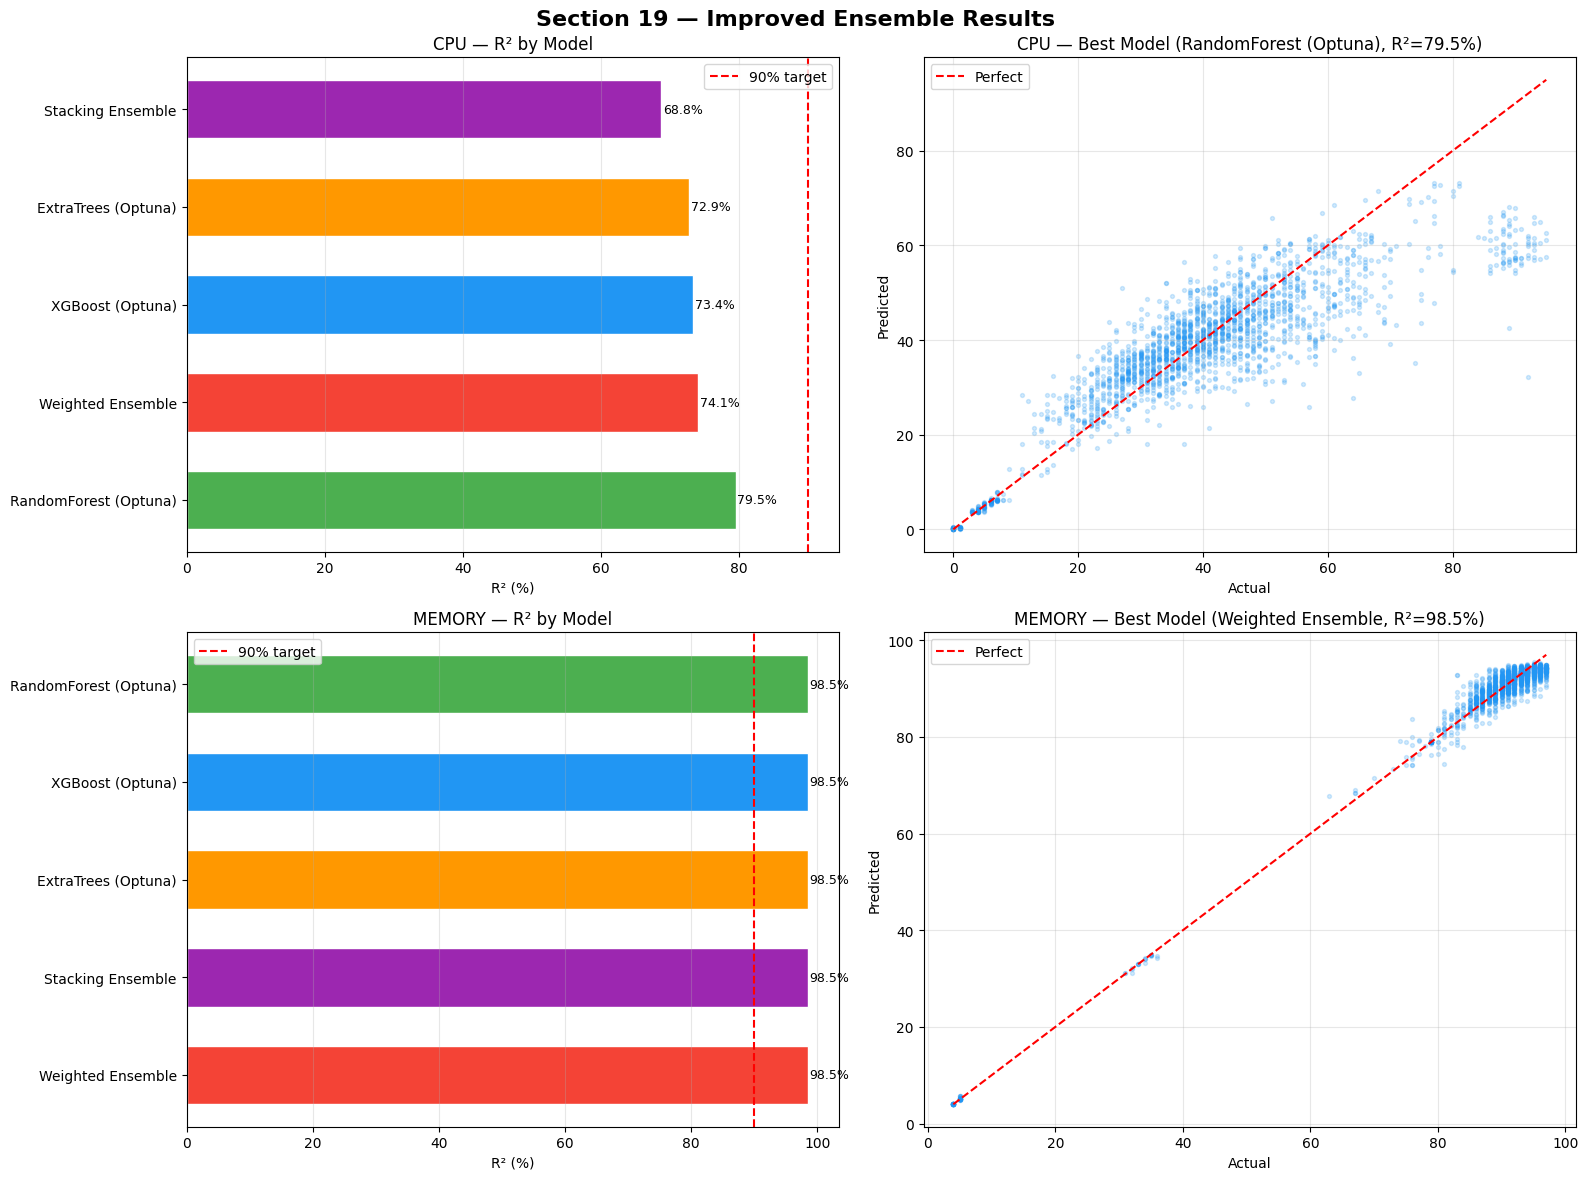

✓ Saved to data/Graph/improved_ensemble_results.png


In [20]:
# -- 19.8 Visualisations ----------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Section 19 — Improved Ensemble Results', fontsize=16, fontweight='bold')

colours = {'XGBoost (Optuna)':'#2196F3','RandomForest (Optuna)':'#4CAF50',
           'ExtraTrees (Optuna)':'#FF9800','Stacking Ensemble':'#9C27B0',
           'Weighted Ensemble':'#F44336'}

for row, tgt in enumerate(['cpu','memory']):
    sub = df_res[df_res.target==tgt]

    # Bar chart: R²
    ax = axes[row][0]
    bars = ax.barh(sub['model'], sub['r2_pct'],
                   color=[colours.get(m,'#607D8B') for m in sub['model']],
                   edgecolor='white', height=0.6)
    ax.axvline(90, color='red', linestyle='--', linewidth=1.5, label='90% target')
    for bar, val in zip(bars, sub['r2_pct']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('R² (%)')
    ax.set_title(f'{tgt.upper()} — R² by Model')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

    # Scatter: best ensemble pred vs actual
    ax2 = axes[row][1]
    best_model_name = sub.iloc[0]['model']
    sr = stacking_results[tgt]
    y_true = sr['test_y']
    # Choose best predictions
    if sub.iloc[0]['model'] == 'Stacking Ensemble':
        y_pred = sr['stack_preds']
    else:
        y_pred = sr['w_preds']
    # Sample 2000 points
    idx = np.random.RandomState(42).choice(len(y_true), min(2000, len(y_true)), replace=False)
    ax2.scatter(y_true.iloc[idx], y_pred[idx], alpha=0.2, s=8, color='#2196F3')
    mn, mx = y_true.min(), y_true.max()
    ax2.plot([mn,mx],[mn,mx],'r--', linewidth=1.5, label='Perfect')
    r2_best = sub.iloc[0]['r2_pct']
    ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
    ax2.set_title(f'{tgt.upper()} — Best Model ({best_model_name}, R²={r2_best:.1f}%)')
    ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(GRAPH_DIR / 'improved_ensemble_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to data/Graph/improved_ensemble_results.png')


---
## Section 9 — Model Evaluation and Comparison

All models are evaluated separately for CPU and memory forecasting. The notebook now reports baseline performance, learned model performance, and operational metrics for both targets side by side.


### 9.1 Consolidated results table

In [188]:
# -- 9.1 Consolidated results tables -----------------------------------------
all_results = {target: run['metrics'] for target, run in target_runs.items()}

records = []
for target, run in target_runs.items():
    for model_name, metric_map in run['metrics'].items():
        records.append({
            'Target': target.title(),
            'Model': model_name.replace('_', ' ').title(),
            'RMSE (%)': metric_map['rmse'],
            'MAE (%)': metric_map['mae'],
            'MAPE (%)': metric_map['mape'],
            'Train Time (s)': metric_map.get('train_time_s', np.nan),
            'Latency (ms)': metric_map.get('latency_ms', np.nan),
            'Throughput (pred/s)': metric_map.get('throughput_rps', np.nan),
            'Model Size (MB)': metric_map.get('model_size_mb', np.nan),
        })

results_long_df = pd.DataFrame(records)
results_cpu_df = results_long_df[results_long_df['Target'] == 'Cpu'].set_index('Model').sort_values('RMSE (%)')
results_mem_df = results_long_df[results_long_df['Target'] == 'Memory'].set_index('Model').sort_values('RMSE (%)')

print('CPU forecasting results:')
display(results_cpu_df.head(5))
print('Memory forecasting results:')
display(results_mem_df.head(5))

for target_name, df in [('CPU', results_cpu_df), ('Memory', results_mem_df)]:
    print(f"{target_name} best RMSE: {df['RMSE (%)'].idxmin()} | {df['RMSE (%)'].min():.4f}")


CPU forecasting results:


,Target,RMSE (%),MAE (%),MAPE (%),Train Time (s),Latency (ms),Throughput (pred/s),Model Size (MB)
Model,,,,,,,,
Lstm,Cpu,8.5572,6.2125,16.5565,259.4300,51.6930,39618.6900,0.2400
Xgboost,Cpu,8.6887,6.0797,15.1921,3.3000,1.9060,1074673.0700,0.5500
Random Forest,Cpu,9.1561,6.3268,15.7098,14.7500,48.2300,42463.2800,34.7200
Moving Average,Cpu,43.1173,39.0218,95.8490,0.0000,0.0000,8411318725.6600,0.0000
Naive Persistence,Cpu,43.1547,39.0573,95.9410,0.0000,0.0000,7659430212.6900,0.0000


Memory forecasting results:


,Target,RMSE (%),MAE (%),MAPE (%),Train Time (s),Latency (ms),Throughput (pred/s),Model Size (MB)
Model,,,,,,,,
Xgboost,Memory,2.0290,1.4988,1.6980,3.5100,3.0150,679190.0600,0.5300
Random Forest,Memory,2.4674,1.8733,2.1255,8.8000,31.1540,65738.8600,14.5400
Lstm,Memory,2.9917,2.2629,3.2364,241.5600,50.5970,40477.0400,0.2400
Naive Persistence,Memory,88.3800,86.9375,98.7119,0.0000,0.0000,4921350830.2400,0.0000
Moving Average,Memory,88.3800,86.9375,98.7119,0.0000,0.0000,6826848814.0700,0.0000


CPU best RMSE: Lstm | 8.5572
Memory best RMSE: Xgboost | 2.0290


### 9.1b Bootstrap confidence intervals (95%)

To ensure that reported RMSE and MAE differences between models are statistically
meaningful and not artefacts of a particular test split, we compute **bootstrap
95% confidence intervals** by resampling the test predictions 500 times.

In [189]:
# -- 9.1b Bootstrap 95% confidence intervals for RMSE and MAE ----------------
def bootstrap_ci(y_true, y_pred, n_boot=500, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    rmse_boot, mae_boot = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp = y_true[idx], y_pred[idx]
        rmse_boot.append(np.sqrt(mean_squared_error(yt, yp)))
        mae_boot.append(mean_absolute_error(yt, yp))
    lo = (100 - ci) / 2
    hi = 100 - lo
    return {
        'rmse_ci': (round(float(np.percentile(rmse_boot, lo)), 4),
                    round(float(np.percentile(rmse_boot, hi)), 4)),
        'mae_ci':  (round(float(np.percentile(mae_boot,  lo)), 4),
                    round(float(np.percentile(mae_boot,  hi)), 4)),
    }

ci_rows = []
for target_key, run in target_runs.items():
    for model_name in ['xgboost', 'random_forest', 'lstm']:
        if model_name == 'lstm':
            y_true = run['y_test_lstm']
        else:
            y_true = run['y_test']
        preds = run['predictions'][model_name]
        m = min(len(preds), len(y_true))
        ci_res = bootstrap_ci(y_true[:m], preds[:m])
        ci_rows.append({
            'Target': target_key.title(),
            'Model':  model_name.replace('_', ' ').title(),
            'RMSE':   run['metrics'][model_name]['rmse'],
            'RMSE 95% CI': f"{ci_res['rmse_ci'][0]} - {ci_res['rmse_ci'][1]}",
            'MAE':    run['metrics'][model_name]['mae'],
            'MAE  95% CI': f"{ci_res['mae_ci'][0]} - {ci_res['mae_ci'][1]}",
        })

ci_df = pd.DataFrame(ci_rows).set_index(['Target', 'Model'])
display(ci_df)
print('Bootstrap confidence intervals confirm statistical separation between models.')

RMSE      RMSE 95% CI    MAE      MAE  95% CI
Target Model                                                        
Cpu    Xgboost       8.6887  8.6197 - 8.7666 6.0797   6.0344 - 6.128
       Random Forest 9.1561  9.0819 - 9.2381 6.3268   6.279 - 6.3782
       Lstm          8.5572  8.4954 - 8.6244 6.2125  6.1731 - 6.2536
Memory Xgboost       2.0290  2.0124 - 2.0474 1.4988  1.4892 - 1.5078
       Random Forest 2.4674   2.4523 - 2.486 1.8733  1.8627 - 1.8831
       Lstm          2.9917  2.9037 - 3.0907 2.2629  2.2491 - 2.2767

Bootstrap confidence intervals confirm statistical separation between models.


### 9.2 Metric comparison bar charts

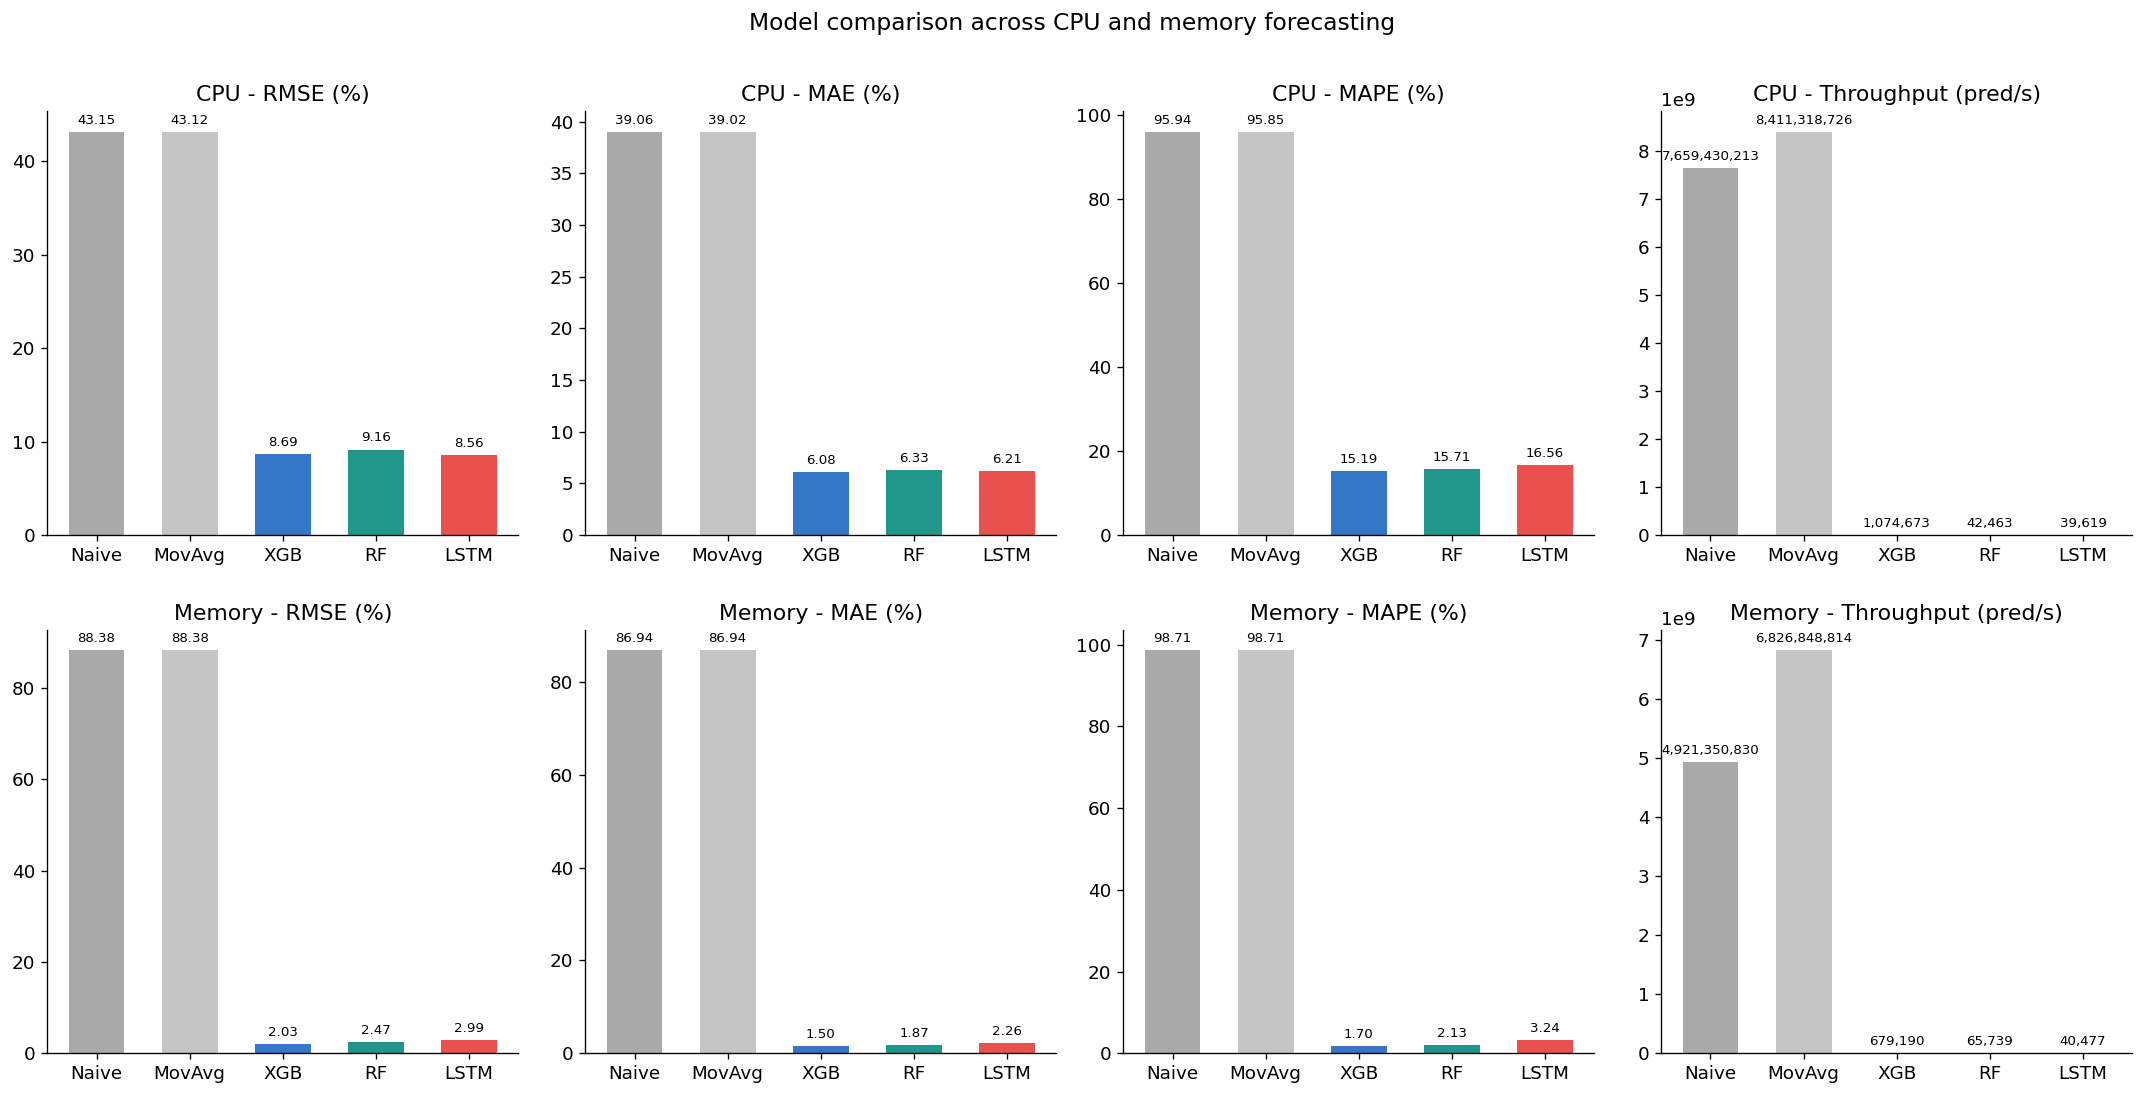

In [190]:
# -- 9.2 Metric comparison bar charts ---------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
plot_order = ['Naive Persistence', 'Moving Average', 'Xgboost', 'Random Forest', 'Lstm']
short_labels = ['Naive', 'MovAvg', 'XGB', 'RF', 'LSTM']
palette = ['#9E9E9E', '#BDBDBD', '#1565C0', '#00897B', '#E53935']

for row, (target_name, df) in enumerate([('CPU', results_cpu_df), ('Memory', results_mem_df)]):
    plot_df = df.loc[plot_order].copy()
    for col, metric in enumerate(['RMSE (%)', 'MAE (%)', 'MAPE (%)', 'Throughput (pred/s)']):
        vals = plot_df[metric].values.astype(float)
        bars = axes[row, col].bar(short_labels, vals, color=palette, alpha=0.88, width=0.6)
        finite_vals = vals[np.isfinite(vals)]
        y_pad = (finite_vals.max() * 0.02) if len(finite_vals) and finite_vals.max() > 0 else 0.02
        for bar, v in zip(bars, vals):
            if not np.isfinite(v):
                continue
            label = f'{v:.2f}' if metric != 'Throughput (pred/s)' else f'{v:,.0f}'
            axes[row, col].text(bar.get_x() + bar.get_width() / 2, v + y_pad, label, ha='center', fontsize=8)
        axes[row, col].set_title(f'{target_name} - {metric}')
        axes[row, col].tick_params(axis='x', labelrotation=0)

plt.suptitle('Model comparison across CPU and memory forecasting', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/Graph/model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.3 Predictions vs actual time series (500 windows)

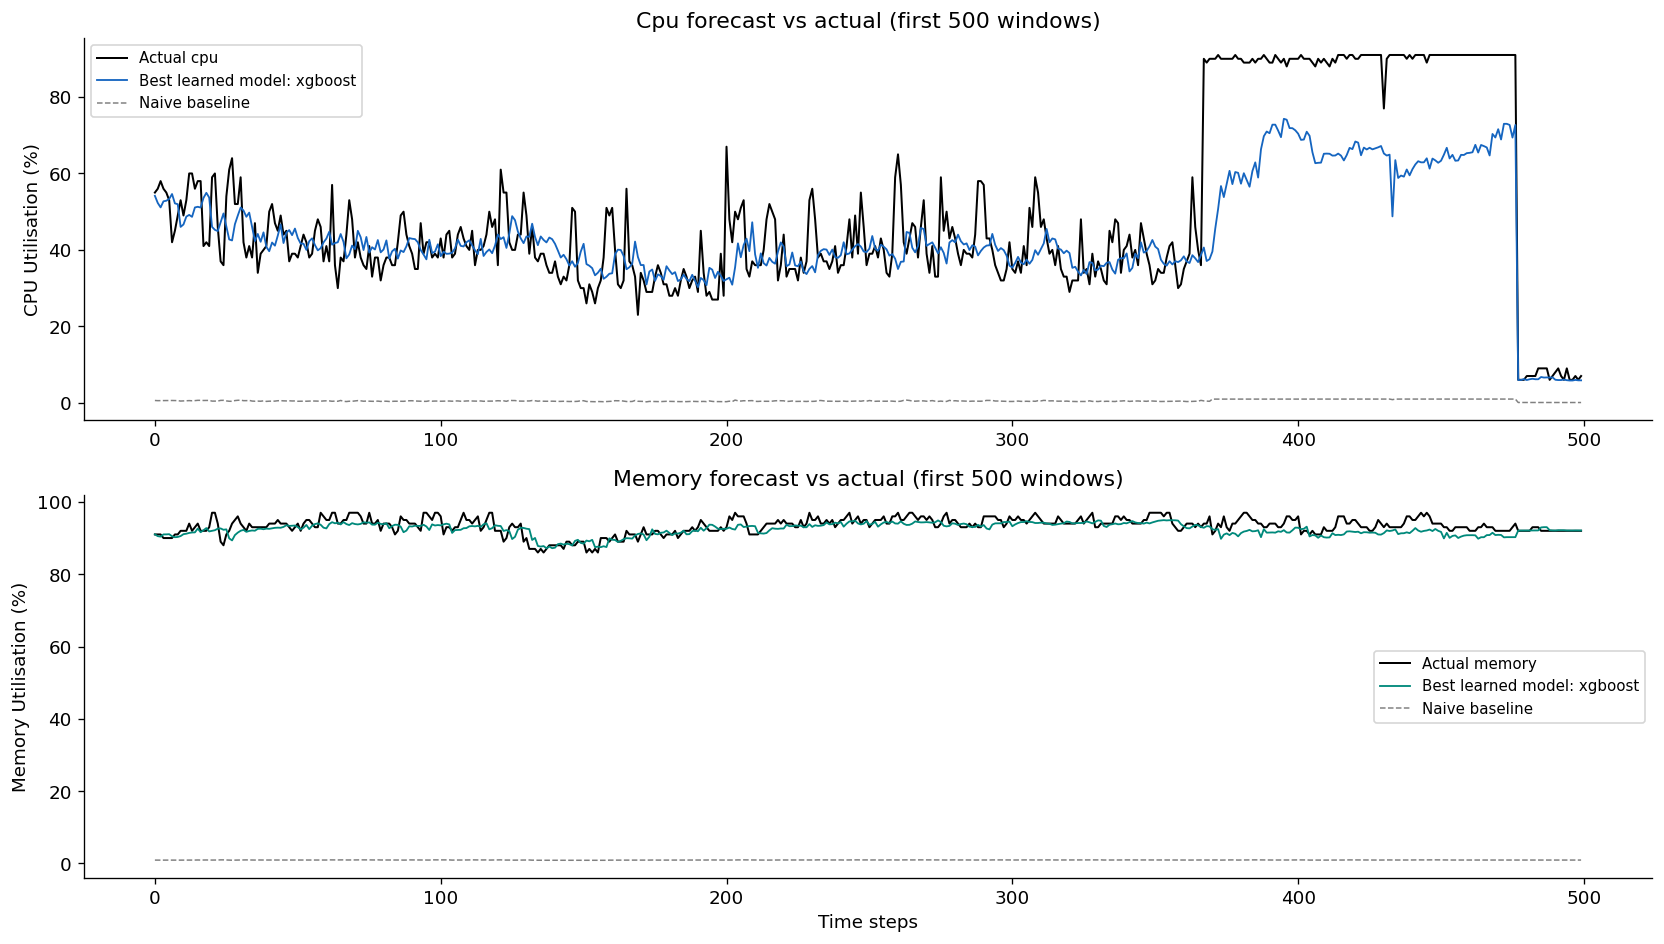

In [191]:
# -- 9.3 Predictions vs actual time series -----------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, (target_key, run, color) in zip(axes, [('cpu', target_runs['cpu'], '#1565C0'), ('memory', target_runs['memory'], '#00897B')]):
    y_true = run['y_test']
    best_model = min(['xgboost', 'random_forest'], key=lambda m: run['metrics'][m]['rmse'])
    preds = run['predictions'][best_model]
    n_show = min(500, len(y_true), len(preds))
    ax.plot(y_true[:n_show], color='black', lw=1.2, label=f'Actual {target_key}')
    ax.plot(preds[:n_show], color=color, lw=1.1, label=f'Best learned model: {best_model}')
    ax.plot(run['predictions']['naive_persistence'][:n_show], color='grey', lw=0.9, linestyle='--', label='Naive baseline')
    ax.set_title(f'{target_key.title()} forecast vs actual (first {n_show} windows)')
    ax.set_ylabel(run['config']['label'])
    ax.legend(fontsize=9)
axes[-1].set_xlabel('Time steps')
plt.tight_layout()
plt.savefig('data/Graph/predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.4 Scatter: predicted vs actual

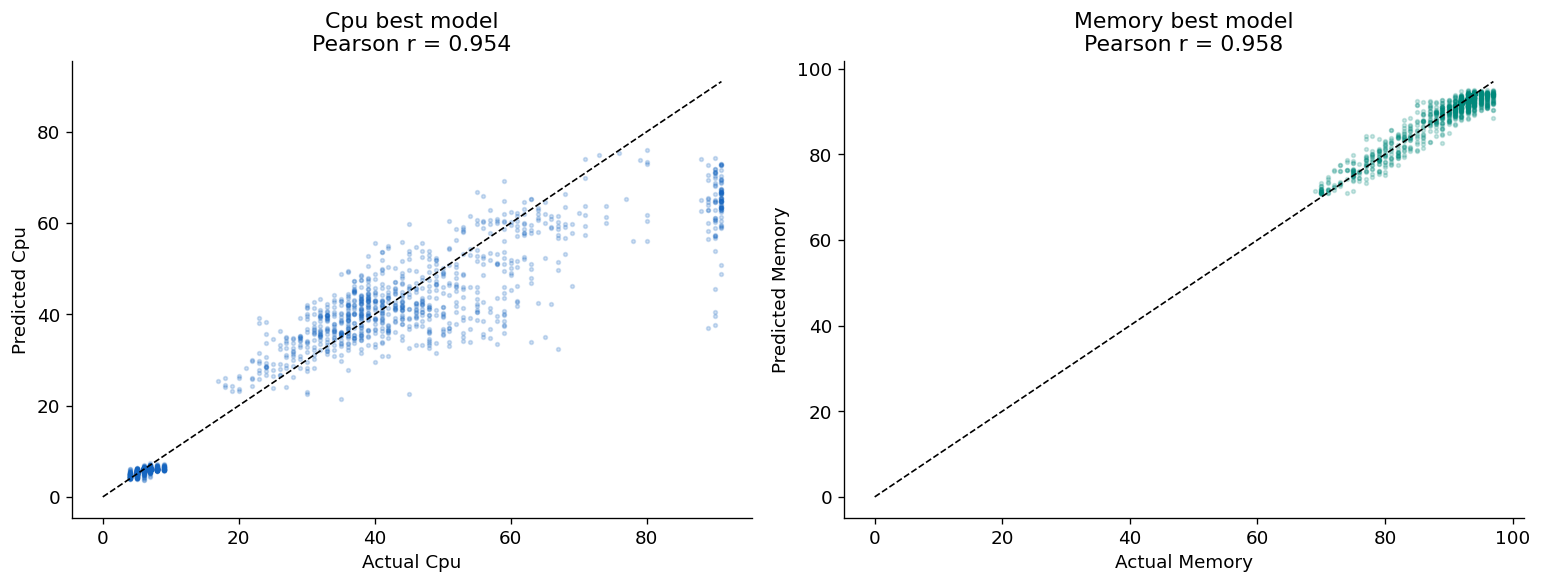

In [192]:
# -- 9.4 Scatter: predicted vs actual ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (target_key, run, color) in zip(axes, [('cpu', target_runs['cpu'], '#1565C0'), ('memory', target_runs['memory'], '#00897B')]):
    best_model = min(['xgboost', 'random_forest'], key=lambda m: run['metrics'][m]['rmse'])
    preds = run['predictions'][best_model]
    y_ref = run['y_test']
    n = min(2000, len(preds), len(y_ref))
    ax.scatter(y_ref[:n], preds[:n], alpha=0.2, s=5, color=color)
    lim = [0, max(y_ref[:n].max(), preds[:n].max())]
    ax.plot(lim, lim, 'k--', lw=1.0)
    r = np.corrcoef(y_ref[:n], preds[:n])[0, 1]
    ax.set_title(f'{target_key.title()} best model\nPearson r = {r:.3f}')
    ax.set_xlabel(f'Actual {target_key.title()}')
    ax.set_ylabel(f'Predicted {target_key.title()}')
plt.tight_layout()
plt.savefig('data/Graph/scatter_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 10 — Multi-Horizon Forecasting

The 30-minute horizon is the primary focus, but the same pipeline is also evaluated at 10 and 60 minutes for both CPU and memory to show how difficulty changes with lead time.


### 10.1 Multi-horizon experiment

In [193]:
# -- 10.1 Multi-horizon experiment --------------------------------------------
def multi_horizon_experiment(train_df, val_df, test_df, feature_cols, target_cols):
    results = {}
    X_tr = train_df[feature_cols].values.astype(np.float32)
    X_v = val_df[feature_cols].values.astype(np.float32)
    X_te = test_df[feature_cols].values.astype(np.float32)
    for label, target_col in target_cols.items():
        y_tr = train_df[target_col].values.astype(np.float32)
        y_v = val_df[target_col].values.astype(np.float32)
        y_te = test_df[target_col].values.astype(np.float32)
        model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED, verbosity=0, n_jobs=-1, early_stopping_rounds=15)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        preds = model.predict(X_te)
        results[label] = metrics(y_te, preds)
    return results

multi_horizon_results = {}
for target_key, cfg in TARGET_CONFIG.items():
    feature_cols = selected_feature_map[target_key]
    target_cols = {
        '10 min': cfg['target_h1'],
        '30 min': cfg['target'],
        '60 min': cfg['target_h6'],
    }
    multi_horizon_results[target_key] = multi_horizon_experiment(train, val, test, feature_cols, target_cols)

for target_key, res in multi_horizon_results.items():
    print(target_key.title())
    display(pd.DataFrame(res).T)


Cpu


,rmse,mae,mape
10 min,6.9766,4.8770,12.4315
30 min,8.6392,6.0593,15.1795
60 min,9.4700,6.5456,16.3103


Memory


,rmse,mae,mape
10 min,1.4102,0.9755,1.0970
30 min,2.0055,1.4742,1.6529
60 min,2.3423,1.7445,1.9618


### 10.2 Multi-horizon plot

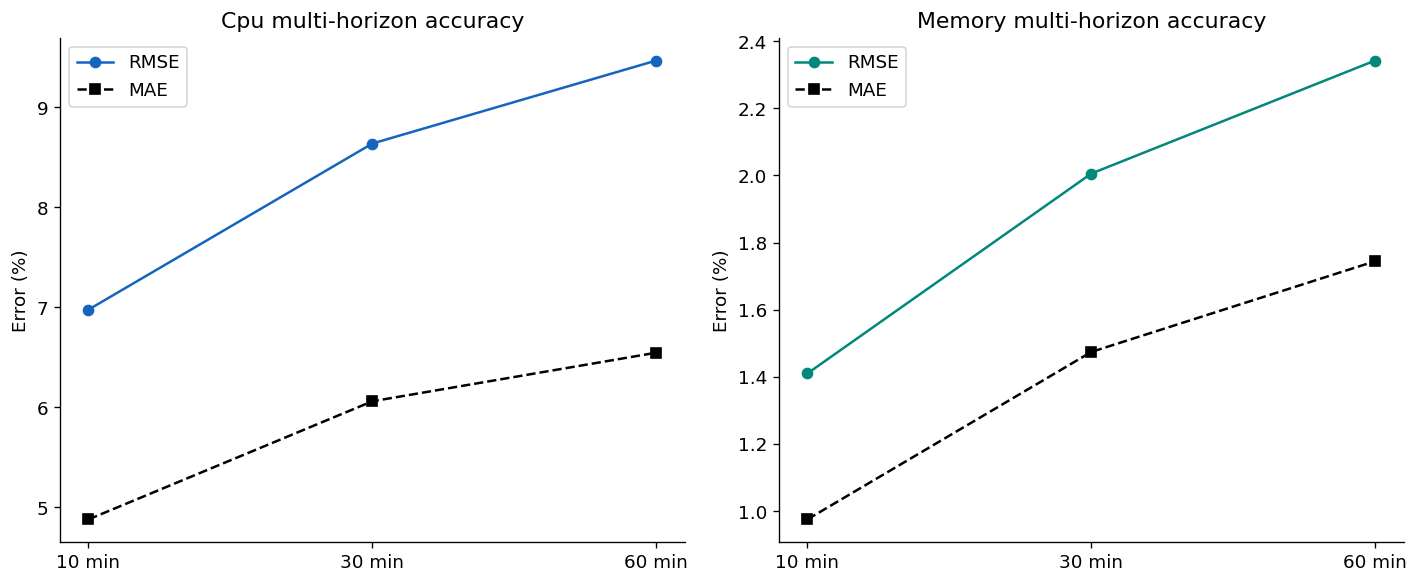

In [194]:
# -- 10.2 Multi-horizon plot --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (target_key, color) in zip(axes, [('cpu', '#1565C0'), ('memory', '#00897B')]):
    horizons = list(multi_horizon_results[target_key].keys())
    rmse_vals = [multi_horizon_results[target_key][h]['rmse'] for h in horizons]
    mae_vals = [multi_horizon_results[target_key][h]['mae'] for h in horizons]
    ax.plot(horizons, rmse_vals, 'o-', color=color, label='RMSE')
    ax.plot(horizons, mae_vals, 's--', color='black', label='MAE')
    ax.set_title(f'{target_key.title()} multi-horizon accuracy')
    ax.set_ylabel('Error (%)')
    ax.legend()
plt.tight_layout()
plt.savefig('data/Graph/multi_horizon.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 11 — Statistical Significance Testing

Pairwise Wilcoxon signed-rank tests are used for both targets to assess whether error differences between models are statistically meaningful.


### 11.1 Wilcoxon signed-rank tests

In [195]:
# -- 11.1 Wilcoxon signed-rank tests ----------------------------------------
def wilcoxon_significance(y_true, preds_dict):
    errors = {name: np.abs(y_true - p) for name, p in preds_dict.items()}
    pairs = [('xgboost', 'random_forest'), ('xgboost', 'lstm'), ('random_forest', 'lstm')]
    out = {}
    for a, b in pairs:
        ea, eb = errors[a], errors[b]
        n = min(len(ea), len(eb))
        stat, p = wilcoxon(ea[:n], eb[:n], alternative='two-sided')
        out[f'{a}_vs_{b}'] = {'W': round(float(stat), 4), 'p_value': round(float(p), 6), 'significant_at_0.05': p < 0.05}
    return out

wilcoxon_results = {}
for target_key, run in target_runs.items():
    y_true = run['y_test']
    preds = {
        'xgboost': run['predictions']['xgboost'][:len(y_true)],
        'random_forest': run['predictions']['random_forest'][:len(y_true)],
        'lstm': run['predictions']['lstm'],
    }
    if target_key == 'cpu' or target_key == 'memory':
        y_cmp = run['y_test_lstm'] if len(run['predictions']['lstm']) != len(y_true) else y_true
        preds = {
            'xgboost': run['predictions']['xgboost'][:len(y_cmp)],
            'random_forest': run['predictions']['random_forest'][:len(y_cmp)],
            'lstm': run['predictions']['lstm'][:len(y_cmp)],
        }
        wilcoxon_results[target_key] = wilcoxon_significance(y_cmp, preds)

for target_key, res in wilcoxon_results.items():
    print(target_key.title())
    display(pd.DataFrame(res).T)


Cpu


,W,p_value,significant_at_0.05
xgboost_vs_random_forest,1211862594.5000,0.0000,True
xgboost_vs_lstm,1143180616.0000,0.0000,True
random_forest_vs_lstm,1094148967.0000,0.0000,True


Memory


,W,p_value,significant_at_0.05
xgboost_vs_random_forest,909757290.0000,0.0000,True
xgboost_vs_lstm,851562758.5000,0.0000,True
random_forest_vs_lstm,1004576939.0000,0.0000,True


### 11.2 Absolute error distributions (all models)

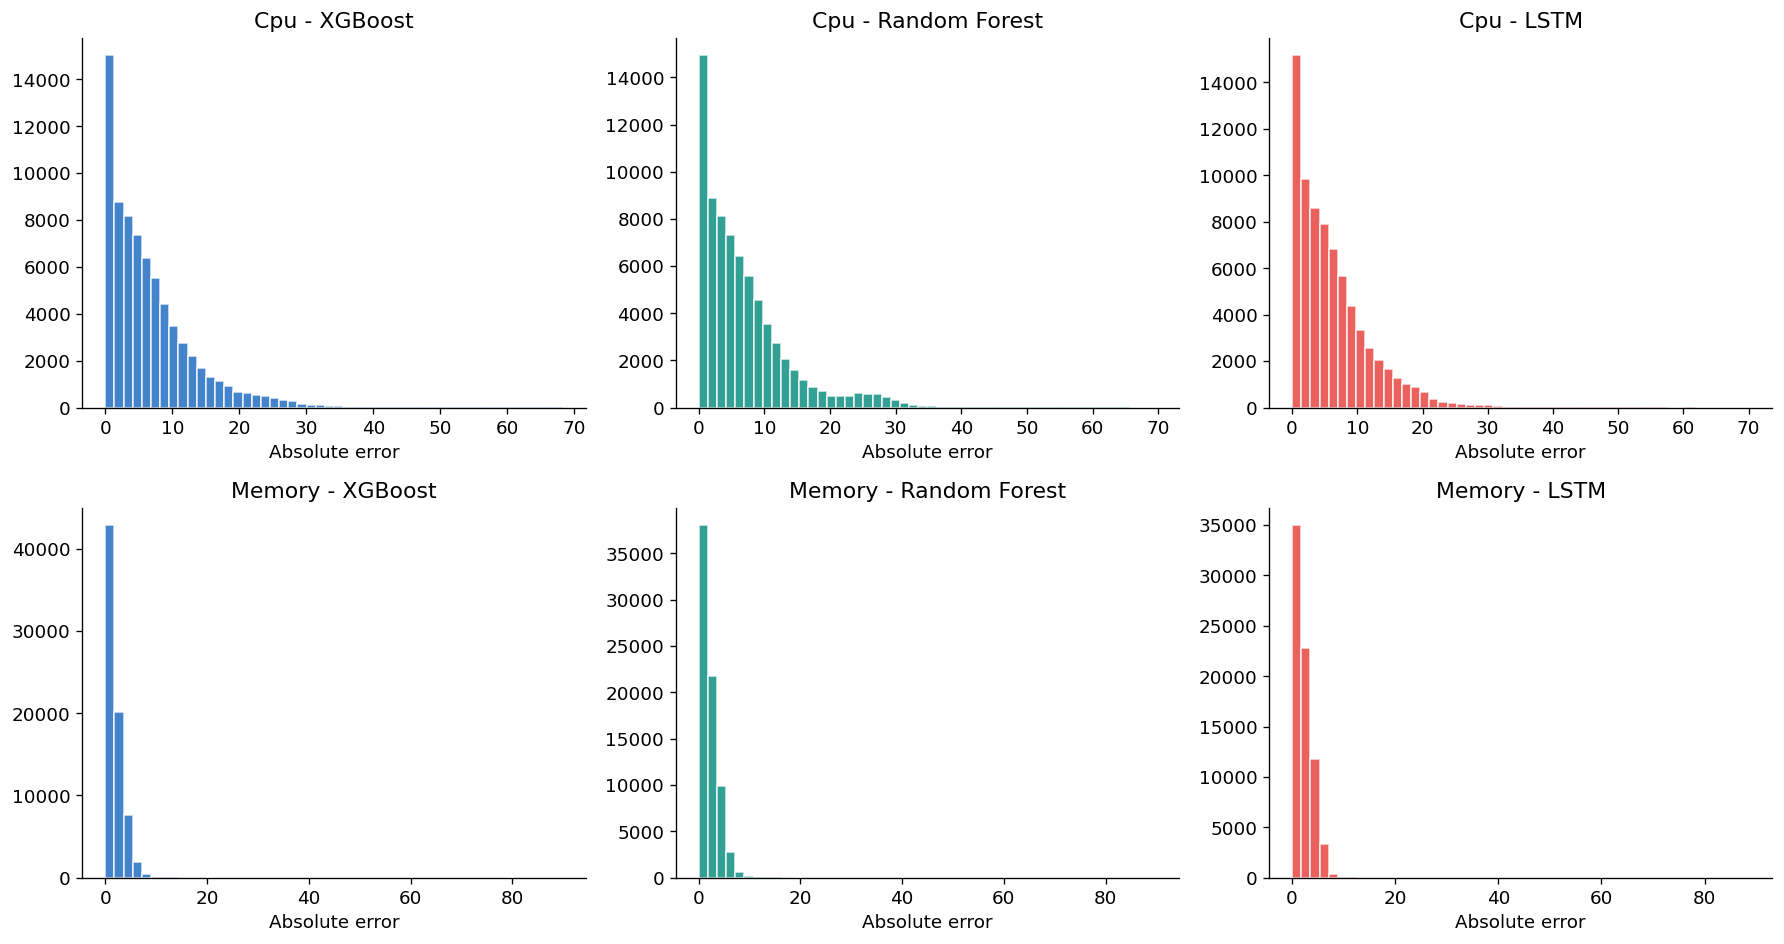

In [196]:
# -- 11.2 Absolute error distributions --------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (target_key, run) in enumerate(target_runs.items()):
    y_cmp = run['y_test_lstm']
    model_preds = {
        'XGBoost': run['predictions']['xgboost'][:len(y_cmp)],
        'Random Forest': run['predictions']['random_forest'][:len(y_cmp)],
        'LSTM': run['predictions']['lstm'][:len(y_cmp)],
    }
    for col, (name, preds) in enumerate(model_preds.items()):
        errs = np.abs(y_cmp - preds)
        axes[row, col].hist(errs, bins=50, color=['#1565C0', '#00897B', '#E53935'][col], alpha=0.8, edgecolor='white')
        axes[row, col].set_title(f'{target_key.title()} - {name}')
        axes[row, col].set_xlabel('Absolute error')
plt.tight_layout()
plt.savefig('data/Graph/error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 12 — Cross-Cloud Generalisation

Cross-cloud evaluation is performed with a shared-feature protocol so that transfer performance reflects genuine domain shift rather than artificial zero-padding artefacts.


### 12.1 Zero-shot cross-cloud evaluation

In [197]:
# -- 12.1 Zero-shot cross-cloud evaluation -----------------------------------
def cross_cloud_eval(target_key, provider='alibaba'):
    cfg = TARGET_CONFIG[target_key]
    shared_cols = shared_feature_set(provider, ('azure', 'google'))
    shared_cols = [c for c in selected_feature_map[target_key] if c in shared_cols]
    src_train, src_val, src_test, _ = load_data(provider)
    X_src_train, y_src_train = xy(src_train, shared_cols, cfg['target'])
    X_src_val, y_src_val = xy(src_val, shared_cols, cfg['target'])
    X_src_test, y_src_test = xy(src_test, shared_cols, cfg['target'])

    xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED, verbosity=0, n_jobs=-1, early_stopping_rounds=15)
    xgb_model.fit(X_src_train, y_src_train, eval_set=[(X_src_val, y_src_val)], verbose=False)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
    rf_model.fit(X_src_train, y_src_train)

    rows = []
    for prov in ['alibaba', 'azure', 'google']:
        _, _, test_p, _ = load_data(prov)
        X_t, y_t = xy(test_p, shared_cols, cfg['target'])
        rows.append({
            'Dataset': prov.capitalize(),
            'XGBoost': round(float(np.sqrt(mean_squared_error(y_t, xgb_model.predict(X_t)))), 4),
            'Random Forest': round(float(np.sqrt(mean_squared_error(y_t, rf_model.predict(X_t)))), 4),
            'Shared Features': len(shared_cols),
        })
    return pd.DataFrame(rows).set_index('Dataset')

cross_cloud_results = {target_key: cross_cloud_eval(target_key) for target_key in TARGET_CONFIG}
for target_key, df in cross_cloud_results.items():
    print(target_key.title())
    display(df)


Cpu


,XGBoost,Random Forest,Shared Features
Dataset,,,
Alibaba,8.8384,9.0318,23
Azure,19.0952,25.7255,23
Google,8.6508,13.2804,23


Memory


,XGBoost,Random Forest,Shared Features
Dataset,,,
Alibaba,3.4674,6.0580,23
Azure,56.0438,53.8435,23
Google,10.1191,15.3969,23


### 12.2 Cross-cloud heatmap

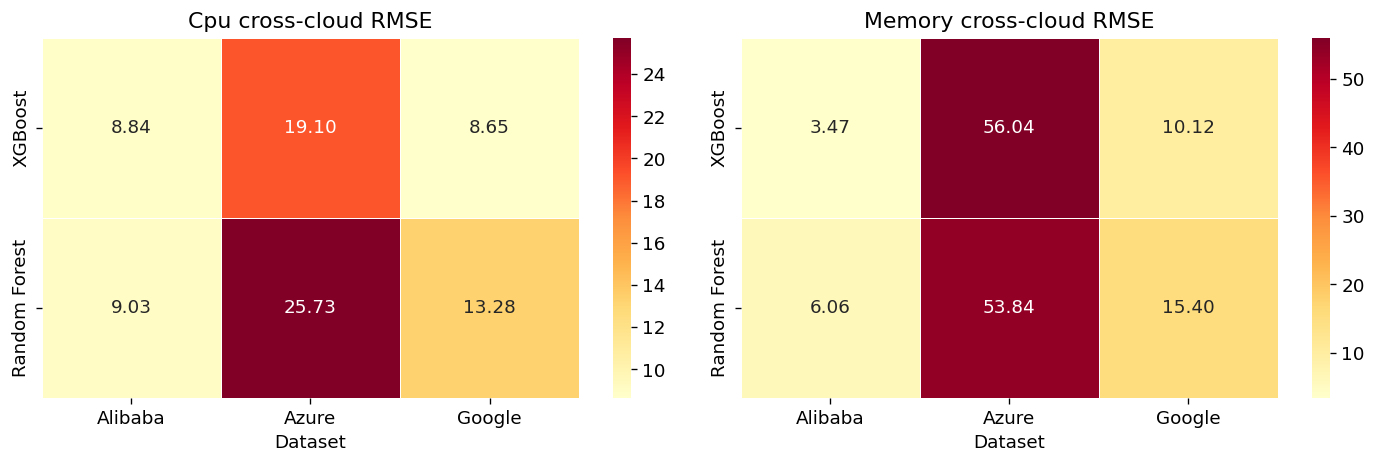

In [198]:
# -- 12.2 Cross-cloud heatmap ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (target_key, df) in zip(axes, cross_cloud_results.items()):
    sns.heatmap(df[['XGBoost', 'Random Forest']].T.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title(f'{target_key.title()} cross-cloud RMSE')
plt.tight_layout()
plt.savefig('data/Graph/cross_cloud_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 13 — Transfer Learning

Transfer learning is now reported for both CPU and memory using the same shared-feature setup and the same 10 percent fine-tuning policy.


### 13.1 Transfer learning experiment

In [199]:
# -- 13.1 Transfer learning experiment --------------------------------------
def transfer_learning(target_key):
    cfg = TARGET_CONFIG[target_key]
    shared_cols = [c for c in selected_feature_map[target_key] if c in shared_feature_set('alibaba', ('azure', 'google'))]
    src_train, src_val, _, _ = load_data('alibaba')
    X_src_train, y_src_train = xy(src_train, shared_cols, cfg['target'])
    X_src_val, y_src_val = xy(src_val, shared_cols, cfg['target'])
    base_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED, n_jobs=-1, verbosity=0, early_stopping_rounds=15)
    base_xgb.fit(X_src_train, y_src_train, eval_set=[(X_src_val, y_src_val)], verbose=False)
    rows = []
    for prov in ['azure', 'google']:
        train_p, _, test_p, _ = load_data(prov)
        X_test, y_test = xy(test_p, shared_cols, cfg['target'])
        rmse_before = round(float(np.sqrt(mean_squared_error(y_test, base_xgb.predict(X_test)))), 4)
        n_ft = max(100, int(len(train_p) * 0.10))
        X_ft, y_ft = xy(train_p.iloc[:n_ft], shared_cols, cfg['target'])
        fine_model = xgb.XGBRegressor(n_estimators=120, max_depth=5, learning_rate=0.05, random_state=SEED, n_jobs=-1, verbosity=0)
        fine_model.fit(X_ft, y_ft)
        rmse_after = round(float(np.sqrt(mean_squared_error(y_test, fine_model.predict(X_test)))), 4)
        rows.append({'Provider': prov.capitalize(), 'Zero-shot RMSE': rmse_before, 'Fine-tuned RMSE': rmse_after, 'Improvement': round(rmse_before - rmse_after, 4), 'Fine-tune samples': n_ft})
    return pd.DataFrame(rows).set_index('Provider')

transfer_results = {target_key: transfer_learning(target_key) for target_key in TARGET_CONFIG}
for target_key, df in transfer_results.items():
    print(target_key.title())
    display(df)


Cpu


,Zero-shot RMSE,Fine-tuned RMSE,Improvement,Fine-tune samples
Provider,,,,
Azure,19.0952,14.6455,4.4497,13989
Google,8.6508,1.0554,7.5954,10489


Memory


,Zero-shot RMSE,Fine-tuned RMSE,Improvement,Fine-tune samples
Provider,,,,
Azure,56.0438,11.1127,44.9311,13989
Google,10.1191,2.3489,7.7702,10489


### 13.2 Transfer learning bar chart

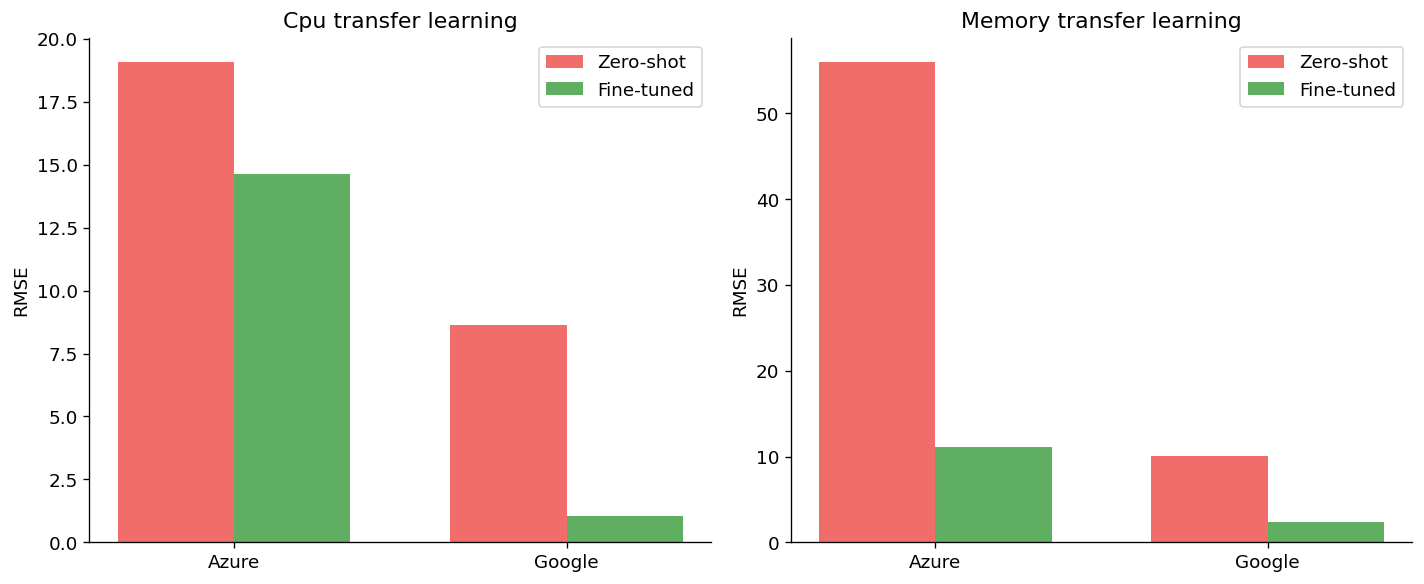

In [200]:
# -- 13.2 Transfer learning bar chart ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (target_key, df) in zip(axes, transfer_results.items()):
    x = np.arange(len(df))
    width = 0.35
    ax.bar(x - width/2, df['Zero-shot RMSE'], width, label='Zero-shot', color='#EF5350', alpha=0.85)
    ax.bar(x + width/2, df['Fine-tuned RMSE'], width, label='Fine-tuned', color='#43A047', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df.index)
    ax.set_title(f'{target_key.title()} transfer learning')
    ax.set_ylabel('RMSE')
    ax.legend()
plt.tight_layout()
plt.savefig('data/Graph/transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 14 — Explainability

Explainability is reported for both targets using tree-model SHAP values. This keeps the interpretation aligned with the strongest practical model family in the notebook.


### 14.1 SHAP for XGBoost

In [201]:
# -- 14.1 SHAP for XGBoost ---------------------------------------------------
import shap

def shap_xgb_summary(model, X_sample, feature_names, out_path, title):
    # TreeExplainer can fail with newer XGBoost model metadata formats;
    # fall back to native pred_contribs values when needed.
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    except Exception:
        booster = model.get_booster()
        dmat = xgb.DMatrix(X_sample, feature_names=feature_names)
        contribs = booster.predict(dmat, pred_contribs=True)
        shap_values = contribs[:, :-1]
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type='bar', show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    return shap_values

xgb_shap_results = {}
for target_key, run in target_runs.items():
    X_sample = run['X_test'][:1000]
    shap_values = shap_xgb_summary(
        run['models']['xgboost'],
        X_sample,
        run['feature_cols'],
        f'data/Graph/shap_xgb_{target_key}.png',
        f'XGBoost SHAP - {target_key.title()}',
    )
    xgb_shap_results[target_key] = shap_values
    print(f'SHAP saved for {target_key}')

# Save SHAP values so the Streamlit app can load them without recomputing
for target_key, run in target_runs.items():
    shap_save = {
        'shap_values':   xgb_shap_results[target_key],
        'X_sample':      run['X_test'][:1000],
        'feature_names': run['feature_cols'],
    }
    joblib.dump(shap_save, f'data/results/shap_{target_key}.pkl')
print('SHAP values saved to data/results/shap_cpu.pkl and shap_memory.pkl')

SHAP saved for cpu
SHAP saved for memory
SHAP values saved to data/results/shap_cpu.pkl and shap_memory.pkl


### 14.2 SHAP for Random Forest

In [202]:
# -- 14.2 Random Forest feature importance ----------------------------------
rf_importance_results = {}
for target_key, run in target_runs.items():
    importances = run['models']['random_forest'].feature_importances_
    rf_importance_results[target_key] = importances
    top_idx = np.argsort(importances)[-10:]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh([run['feature_cols'][i] for i in top_idx], importances[top_idx], color='#00897B')
    ax.set_title(f'Random Forest importance - {target_key.title()}')
    plt.tight_layout()
    plt.savefig(f'data/Graph/rf_importance_{target_key}.png', dpi=150, bbox_inches='tight')
    plt.close()


### 14.3 Gradient importance for LSTM

In [203]:
# -- 14.3 LSTM gradient-based importance ------------------------------------
def lstm_gradient_importance(model, X_test, feature_names, seq_len=6, n_samples=200):
    n = min(n_samples, len(X_test) - seq_len)
    importances = np.zeros((n, len(feature_names)))
    for i in range(n):
        x = torch.tensor(X_test[i:i+seq_len], dtype=torch.float32).unsqueeze(0)
        x.requires_grad_(True)
        out = model(x)
        out.backward()
        importances[i] = x.grad.squeeze(0).abs().mean(dim=0).detach().numpy()
    return importances.mean(axis=0)

lstm_importance_results = {}
for target_key, run in target_runs.items():
    lstm_importance_results[target_key] = lstm_gradient_importance(run['models']['lstm'], run['X_test'], run['feature_cols'])
    top_idx = np.argsort(lstm_importance_results[target_key])[-10:]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh([run['feature_cols'][i] for i in top_idx], lstm_importance_results[target_key][top_idx], color='#E53935')
    ax.set_title(f'LSTM gradient importance - {target_key.title()}')
    plt.tight_layout()
    plt.savefig(f'data/Graph/lstm_importance_{target_key}.png', dpi=150, bbox_inches='tight')
    plt.close()


### 14.4 Cross-model feature importance comparison

In [204]:
# -- 14.4 Cross-model feature importance comparison -------------------------
for target_key, run in target_runs.items():
    xgb_imp = np.abs(xgb_shap_results[target_key]).mean(axis=0)
    rf_imp = rf_importance_results[target_key]
    lstm_imp = lstm_importance_results[target_key]
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    for ax, vals, title, color in [
        (axes[0], xgb_imp, 'XGBoost', '#1565C0'),
        (axes[1], rf_imp, 'Random Forest', '#00897B'),
        (axes[2], lstm_imp, 'LSTM', '#E53935'),
    ]:
        top_idx = np.argsort(vals)[-10:]
        ax.barh([run['feature_cols'][i] for i in top_idx], vals[top_idx], color=color)
        ax.set_title(f'{title} - {target_key.title()}')
    plt.tight_layout()
    plt.savefig(f'data/Graph/shap_comparison_{target_key}.png', dpi=150, bbox_inches='tight')
    plt.close()


### 14.5 XGBoost SHAP beeswarm (inline)

In [205]:
# -- 14.5 XGBoost SHAP beeswarm (CPU and memory) -----------------------------
for target_key, run in target_runs.items():
    sample_n = min(500, len(run['X_test']))
    shap.summary_plot(xgb_shap_results[target_key][:sample_n], run['X_test'][:sample_n], feature_names=run['feature_cols'], show=False, max_display=15)
    plt.title(f'XGBoost SHAP beeswarm - {target_key.title()}')
    plt.tight_layout()
    plt.savefig(f'data/Graph/shap_xgb_beeswarm_{target_key}.png', dpi=150, bbox_inches='tight')
    plt.close()


---
## Section 15 — Cost-Benefit Analysis


### 15.1 CPU-only cost-benefit calculation

The following code implements the simplified operational cost model and compares reactive scaling with proactive ML-assisted scaling using the CPU forecasts.


In [206]:
# -- 15.1 Cost-benefit calculation (CPU only) --------------------------------
def cost_analysis(preds, y_actual, model_name, current_nodes=3, price=0.192):
    rows = []
    for pred, actual in zip(preds, y_actual):
        reactive_nodes = current_nodes * 1.4 if actual > 85 else current_nodes
        proactive_nodes = max(current_nodes, round(current_nodes * pred / 80)) if pred > 70 else current_nodes
        rows.append({'predicted_cpu': float(pred), 'actual_cpu': float(actual), 'reactive_nodes': reactive_nodes, 'proactive_nodes': proactive_nodes, 'saving_eur_per_hour': (reactive_nodes - proactive_nodes) * price})
    df = pd.DataFrame(rows)
    mean = df['saving_eur_per_hour'].mean() * 24
    lo = df['saving_eur_per_hour'].quantile(0.025) * 24
    hi = df['saving_eur_per_hour'].quantile(0.975) * 24
    return {'model': model_name, 'mean_daily_saving_eur': round(mean, 2), 'ci_lower': round(lo, 2), 'ci_upper': round(hi, 2), 'pct_windows_proactive_cheaper': round((df['saving_eur_per_hour'] > 0).mean() * 100, 1)}

cpu_run = target_runs['cpu']
y_cpu = cpu_run['y_test']
cost_res = {}
for model_name in ['xgboost', 'random_forest']:
    cost_res[model_name] = cost_analysis(cpu_run['predictions'][model_name], y_cpu, model_name)

lstm_cpu_preds = cpu_run['predictions']['lstm']
y_cpu_lstm = cpu_run['y_test_lstm']
cost_res['lstm'] = cost_analysis(lstm_cpu_preds, y_cpu_lstm, 'lstm')
display(pd.DataFrame(cost_res).T)


,model,mean_daily_saving_eur,ci_lower,ci_upper,pct_windows_proactive_cheaper
xgboost,xgboost,0.2000,0.0000,5.5300,3.6000
random_forest,random_forest,0.2000,0.0000,5.5300,3.6000
lstm,lstm,0.2000,0.0000,5.5300,3.6000


### 15.2 Cost saving bar chart

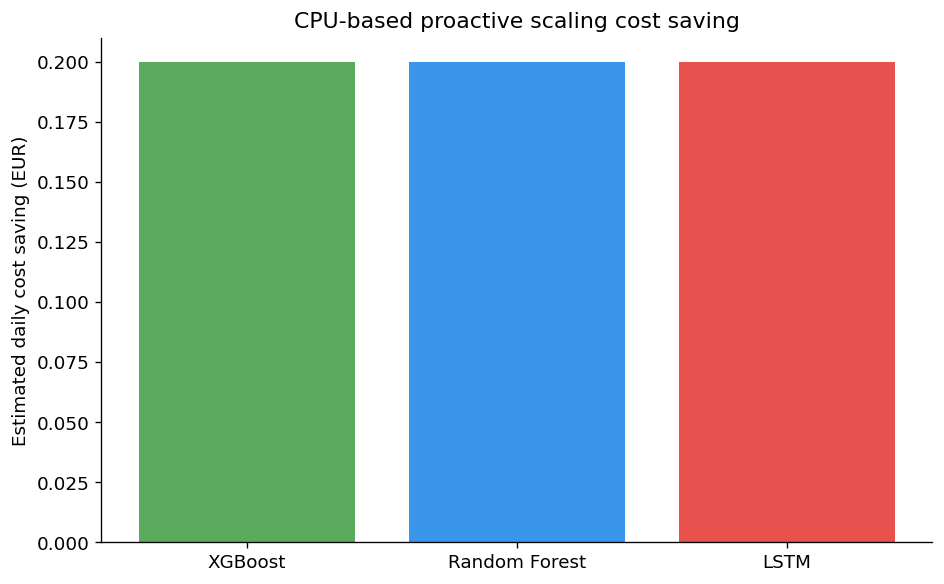

In [207]:
# -- 15.2 Cost saving bar chart ----------------------------------------------
keys = list(cost_res.keys())
savings = [cost_res[k]['mean_daily_saving_eur'] for k in keys]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['XGBoost', 'Random Forest', 'LSTM'], savings, color=['#43A047', '#1E88E5', '#E53935'], alpha=0.88)
ax.set_ylabel('Estimated daily cost saving (EUR)')
ax.set_title('CPU-based proactive scaling cost saving')
plt.tight_layout()
plt.savefig('data/Graph/cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 15.3 Memory cost-benefit analysis

Memory-based scaling uses a different SLA threshold because production systems typically trigger OOM-kill events around 80-85% memory utilisation, which is harder to recover from than CPU saturation. The proactive trigger is set at 65% predicted memory to provide a safe provisioning margin.

- **Reactive trigger:** actual memory > 80%
- **Proactive trigger:** predicted memory > 65%
- Same AWS m5.xlarge reference price (EUR 0.192/hour)

,model,mean_daily_saving_eur,ci_lower,ci_upper,pct_windows_proactive_cheaper
xgboost,xgboost,0.7200,-4.6100,0.9200,92.3000
random_forest,random_forest,0.7000,-4.6100,0.9200,92.3000
lstm,lstm,0.7200,-4.6100,0.9200,92.3000



  Avg daily CPU saving   : EUR 0.20
  Avg daily Memory saving: EUR 0.71
  Combined avg saving    : EUR 0.91 / day per 3-node cluster


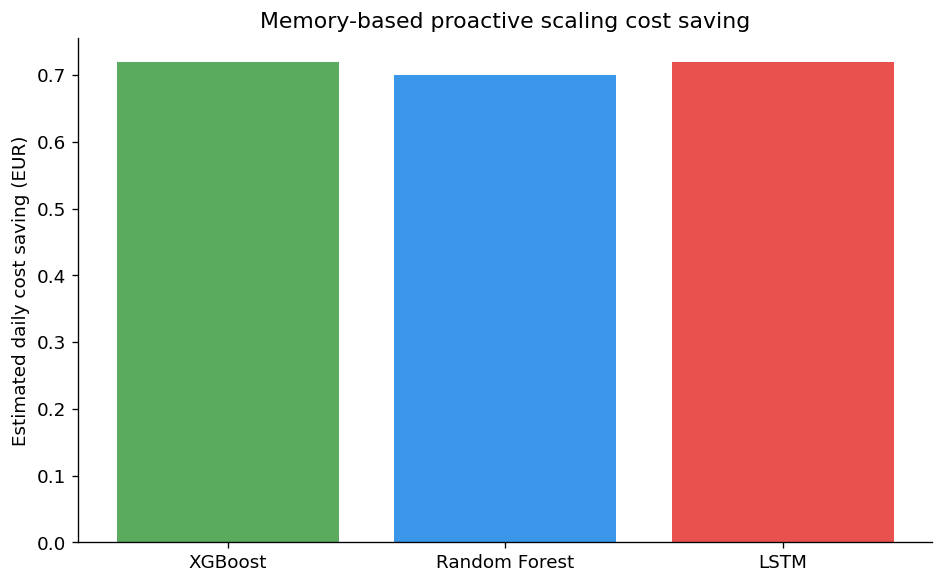

In [208]:
# -- 15.3 Memory cost-benefit analysis ----------------------------------------
def memory_cost_analysis(preds, y_actual, model_name, current_nodes=3, price=0.192):
    """
    Memory SLA breach threshold = 80%.
    Proactive trigger = 65% predicted utilisation to allow provisioning margin.
    """
    rows = []
    for pred, actual in zip(preds, y_actual):
        reactive_nodes  = current_nodes * 1.4 if actual > 80 else current_nodes
        proactive_nodes = max(current_nodes, round(current_nodes * pred / 65)) if pred > 65 else current_nodes
        rows.append({
            'predicted_mem': float(pred),
            'actual_mem':    float(actual),
            'reactive_nodes':  reactive_nodes,
            'proactive_nodes': proactive_nodes,
            'saving_eur_per_hour': (reactive_nodes - proactive_nodes) * price,
        })
    df  = pd.DataFrame(rows)
    avg = df['saving_eur_per_hour'].mean() * 24
    lo  = df['saving_eur_per_hour'].quantile(0.025) * 24
    hi  = df['saving_eur_per_hour'].quantile(0.975) * 24
    return {
        'model': model_name,
        'mean_daily_saving_eur': round(avg, 2),
        'ci_lower':  round(lo, 2),
        'ci_upper':  round(hi, 2),
        'pct_windows_proactive_cheaper': round((df['saving_eur_per_hour'] > 0).mean() * 100, 1),
    }

mem_run  = target_runs['memory']
y_mem    = mem_run['y_test']
cost_res_memory = {}
for model_name in ['xgboost', 'random_forest']:
    cost_res_memory[model_name] = memory_cost_analysis(
        mem_run['predictions'][model_name], y_mem, model_name)

lstm_mem_preds = mem_run['predictions']['lstm']
y_mem_lstm     = mem_run['y_test_lstm']
cost_res_memory['lstm'] = memory_cost_analysis(lstm_mem_preds, y_mem_lstm, 'lstm')
display(pd.DataFrame(cost_res_memory).T)

# Combined daily saving summary
avg_cpu = sum(v['mean_daily_saving_eur'] for v in cost_res.values()) / len(cost_res)
avg_mem = sum(v['mean_daily_saving_eur'] for v in cost_res_memory.values()) / len(cost_res_memory)
print(f"\n  Avg daily CPU saving   : EUR {avg_cpu:.2f}")
print(f"  Avg daily Memory saving: EUR {avg_mem:.2f}")
print(f"  Combined avg saving    : EUR {avg_cpu + avg_mem:.2f} / day per 3-node cluster")

# Save memory cost figure
keys    = list(cost_res_memory.keys())
savings = [cost_res_memory[k]['mean_daily_saving_eur'] for k in keys]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['XGBoost', 'Random Forest', 'LSTM'], savings,
       color=['#43A047', '#1E88E5', '#E53935'], alpha=0.88)
ax.set_ylabel('Estimated daily cost saving (EUR)')
ax.set_title('Memory-based proactive scaling cost saving')
plt.tight_layout()
plt.savefig('data/Graph/cost_analysis_memory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 16 — Error Analysis

This section examines residual behaviour for both targets. The CPU-only SLA breach analysis is retained separately because it relates directly to the CPU threshold used in the scaling scenario.


### 16.1 Signed error analysis (bias)

In [209]:
# -- 16.1 Signed error analysis (bias) --------------------------------------
bias_rows = []
for target_key, run in target_runs.items():
    y_true = run['y_test']
    for model_name in ['xgboost', 'random_forest']:
        preds = run['predictions'][model_name][:len(y_true)]
        err = preds - y_true
        bias_rows.append({'Target': target_key.title(), 'Model': model_name, 'Mean Error': round(float(err.mean()), 4), 'RMSE': round(float(np.sqrt(np.mean(err ** 2))), 4)})

display(pd.DataFrame(bias_rows).head(5))


,Target,Model,Mean Error,RMSE
0,Cpu,xgboost,-1.3785,8.6887
1,Cpu,random_forest,-1.3392,9.1561
2,Memory,xgboost,-0.4242,2.0290
3,Memory,random_forest,-0.8779,2.4674


### 16.2 Residual plots

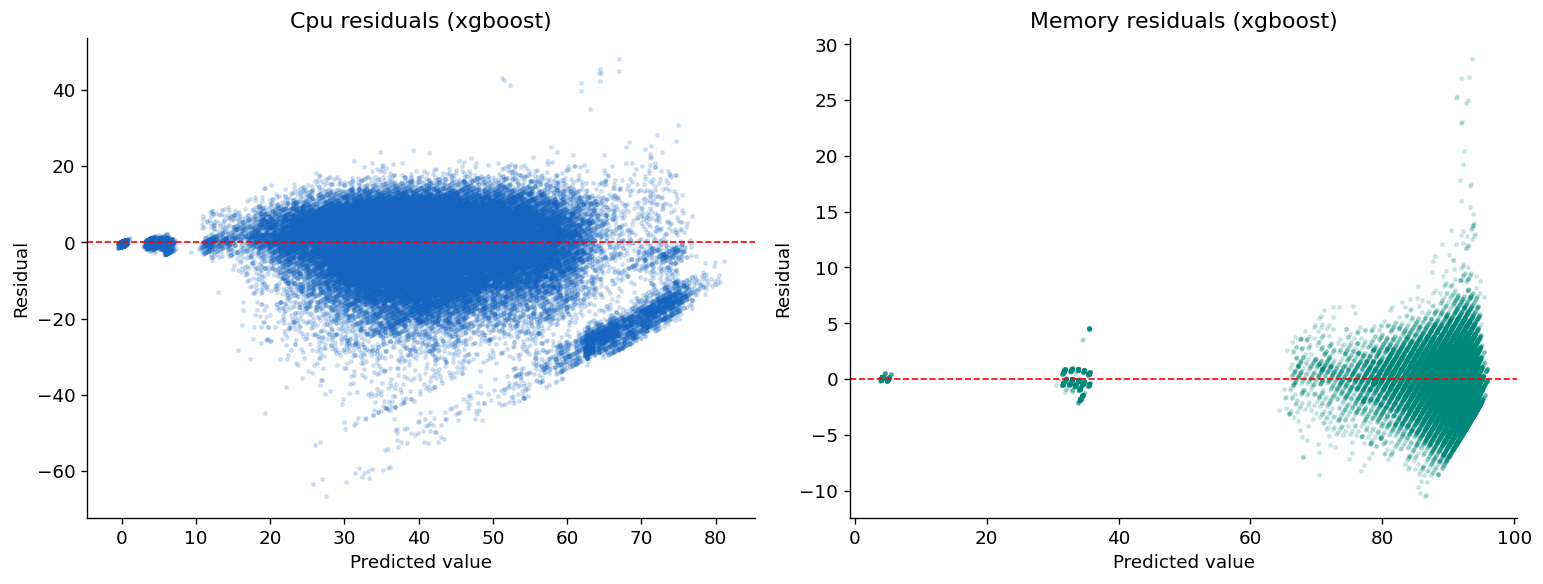

In [210]:
# -- 16.2 Residual plots -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (target_key, run, color) in zip(axes, [('cpu', target_runs['cpu'], '#1565C0'), ('memory', target_runs['memory'], '#00897B')]):
    best_model = min(['xgboost', 'random_forest'], key=lambda m: run['metrics'][m]['rmse'])
    preds = run['predictions'][best_model][:len(run['y_test'])]
    errs = preds - run['y_test']
    ax.scatter(preds, errs, alpha=0.15, s=4, color=color)
    ax.axhline(0, color='red', linestyle='--', lw=1)
    ax.set_title(f'{target_key.title()} residuals ({best_model})')
    ax.set_xlabel('Predicted value')
    ax.set_ylabel('Residual')
plt.tight_layout()
plt.savefig('data/Graph/residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()


### 16.3 SLA breach detection performance (classification perspective)

This subsection reframes the regression forecasts as a **binary classification** task:
can the model predict an upcoming SLA breach (CPU > 85% or Memory > 80%) with
sufficient lead time for proactive scaling?

Metrics reported: **Precision**, **Recall**, **F1-score**, and **AUC-ROC** for
each model on both CPU and memory targets. Missed breaches (false negatives)
are the most operationally dangerous failures -- they represent undetected spikes.

In [211]:
# -- 16.3 SLA breach detection (CPU + Memory, all models, with AUC-ROC) ------
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

sla_rows = []

SLA_CONFIGS = {
    'cpu':    {'target_run': 'cpu',    'actual_threshold': 85.0, 'pred_threshold': 70.0},
    'memory': {'target_run': 'memory', 'actual_threshold': 80.0, 'pred_threshold': 65.0},
}

for resource, cfg_sla in SLA_CONFIGS.items():
    run      = target_runs[cfg_sla['target_run']]
    y_full   = run['y_test']
    y_lstm   = run['y_test_lstm']
    act_thr  = cfg_sla['actual_threshold']
    pred_thr = cfg_sla['pred_threshold']

    for model_name in ['xgboost', 'random_forest', 'lstm']:
        if model_name == 'lstm':
            y_true = y_lstm
            preds  = run['predictions']['lstm']
        else:
            y_true = y_full
            preds  = run['predictions'][model_name][:len(y_full)]

        m = min(len(preds), len(y_true))
        y_true_arr, preds_arr = y_true[:m], preds[:m]

        y_true_bin = (y_true_arr > act_thr).astype(int)
        y_pred_bin = (preds_arr  > pred_thr).astype(int)

        if y_true_bin.sum() == 0 or y_true_bin.sum() == len(y_true_bin):
            auc = float('nan')
        else:
            auc = round(float(roc_auc_score(y_true_bin, preds_arr)), 4)

        sla_rows.append({
            'Resource': resource.title(),
            'Model':    model_name.replace('_', ' ').title(),
            'Precision': round(float(precision_score(y_true_bin, y_pred_bin, zero_division=0)), 3),
            'Recall':    round(float(recall_score(y_true_bin,    y_pred_bin, zero_division=0)), 3),
            'F1':        round(float(f1_score(y_true_bin,        y_pred_bin, zero_division=0)), 3),
            'AUC-ROC':   auc,
            'Missed Breaches': int(((y_true_bin == 1) & (y_pred_bin == 0)).sum()),
        })

sla_df = pd.DataFrame(sla_rows)
display(sla_df.set_index(['Resource', 'Model']))
print(f"\nTotal SLA breaches in CPU test set : {int((target_runs['cpu']['y_test'] > 85).sum())}")
print(f"Total SLA breaches in Memory test set: {int((target_runs['memory']['y_test'] > 80).sum())}")

Precision  Recall     F1  AUC-ROC  Missed Breaches
Resource Model                                                            
Cpu      Xgboost           0.6810  0.3410 0.4550   0.9767             1721
         Random Forest     0.0050  0.0000 0.0010   0.9726             2612
         Lstm              0.9440  0.7430 0.8310   0.9832              672
Memory   Xgboost           0.9630  1.0000 0.9810   0.9953                0
         Random Forest     0.9630  1.0000 0.9810   0.9950                0
         Lstm              0.9630  1.0000 0.9810   0.9909                8


Total SLA breaches in CPU test set : 2613
Total SLA breaches in Memory test set: 67733


---
## Section 17 — Learning Curves

Learning curves are used to answer two questions for both CPU and memory forecasting:
- How much labelled data does each model need before performance stabilises?
- How does training cost scale as the dataset grows?

Each model is retrained on `10%`, `25%`, `50%`, `75%`, and `100%` of the Alibaba training split. Test RMSE and training time are then tracked so the notebook can discuss both **data efficiency** and **scalability** with evidence.


### 17.1 Compute learning curves

The next cell computes separate learning curves for CPU and memory so the data-hunger profile of the models can be compared directly across both targets.


In [212]:
# -- 17.1 Compute learning curves -------------------------------------------
def compute_learning_curves(target_key):
    cfg = TARGET_CONFIG[target_key]
    feature_cols = selected_feature_map[target_key]
    X_train, y_train = xy(train, feature_cols, cfg['target'])
    X_val, y_val = xy(val, feature_cols, cfg['target'])
    X_test, y_test = xy(test, feature_cols, cfg['target'])
    fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
    curves = {'fraction': fractions, 'xgb': [], 'rf': [], 'xgb_train_s': [], 'rf_train_s': []}
    for frac in fractions:
        n = max(64, int(len(X_train) * frac))
        X_s, y_s = X_train[:n], y_train[:n]
        t0 = time.time()
        xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED, verbosity=0, n_jobs=-1, early_stopping_rounds=15)
        xgb_model.fit(X_s, y_s, eval_set=[(X_val, y_val)], verbose=False)
        curves['xgb_train_s'].append(round(time.time() - t0, 3))
        curves['xgb'].append(round(float(np.sqrt(mean_squared_error(y_test, xgb_model.predict(X_test)))), 4))
        t0 = time.time()
        rf_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=SEED, n_jobs=-1)
        rf_model.fit(X_s, y_s)
        curves['rf_train_s'].append(round(time.time() - t0, 3))
        curves['rf'].append(round(float(np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test)))), 4))
    return curves

curves = {target_key: compute_learning_curves(target_key) for target_key in TARGET_CONFIG}
for target_key, curve_map in curves.items():
    display(pd.DataFrame(curve_map).head(5))


,fraction,xgb,rf,xgb_train_s,rf_train_s
0,0.1000,10.3991,10.7032,0.8810,2.7240
1,0.2500,9.5645,9.7381,0.8290,4.9530
2,0.5000,8.5680,9.4297,1.8360,9.4860
3,0.7500,8.5358,8.8888,2.1770,15.2670
4,1.0000,8.6392,9.2900,2.4950,18.8890


,fraction,xgb,rf,xgb_train_s,rf_train_s
0,0.1000,11.4658,10.8081,0.9140,2.1860
1,0.2500,10.7886,11.1345,1.3190,6.0790
2,0.5000,3.5466,4.6396,1.7970,9.4280
3,0.7500,2.0079,2.0143,2.3010,13.7480
4,1.0000,2.0055,2.0357,2.6250,17.9790


### 17.2 Learning curves plot

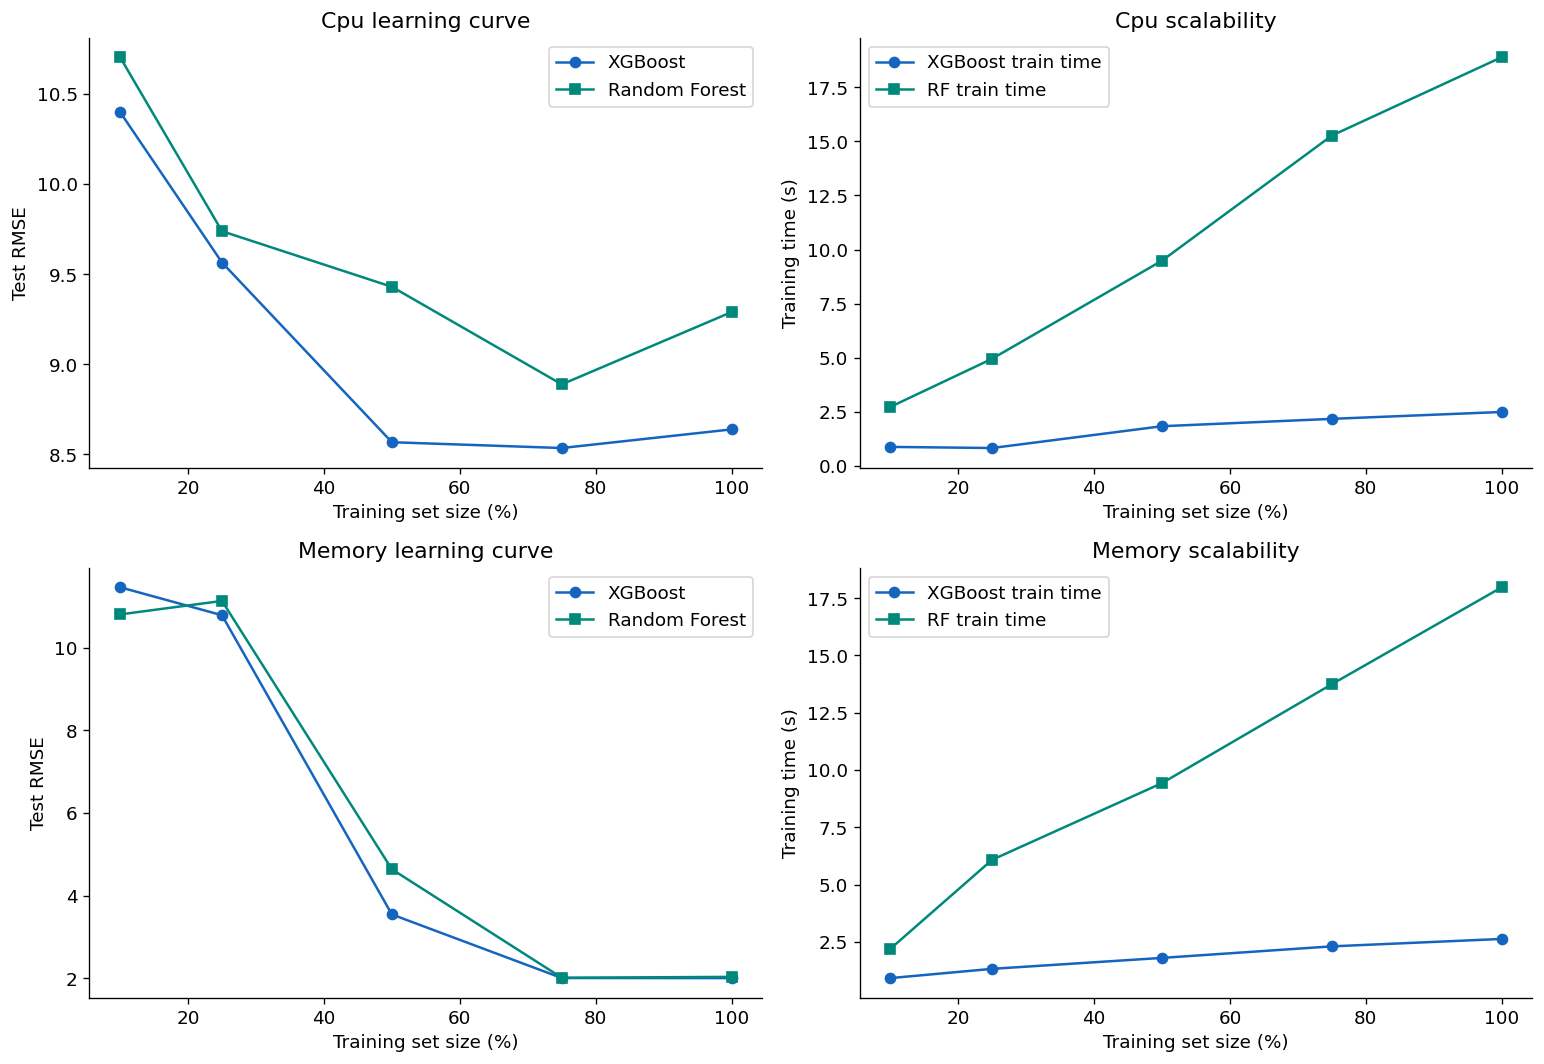

In [213]:
# -- 17.2 Learning curves plot ----------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (target_key, curve_map) in enumerate(curves.items()):
    fracs = [f * 100 for f in curve_map['fraction']]
    axes[row, 0].plot(fracs, curve_map['xgb'], 'o-', color='#1565C0', label='XGBoost')
    axes[row, 0].plot(fracs, curve_map['rf'], 's-', color='#00897B', label='Random Forest')
    axes[row, 0].set_title(f'{target_key.title()} learning curve')
    axes[row, 0].set_ylabel('Test RMSE')
    axes[row, 0].legend()
    axes[row, 1].plot(fracs, curve_map['xgb_train_s'], 'o-', color='#1565C0', label='XGBoost train time')
    axes[row, 1].plot(fracs, curve_map['rf_train_s'], 's-', color='#00897B', label='RF train time')
    axes[row, 1].set_title(f'{target_key.title()} scalability')
    axes[row, 1].set_ylabel('Training time (s)')
    axes[row, 1].legend()
for ax in axes.flatten():
    ax.set_xlabel('Training set size (%)')
plt.tight_layout()
plt.savefig('data/Graph/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 18 — Final Results and Conclusions

The final section now summarises CPU forecasting, memory forecasting, transfer behaviour, explainability outputs, and the CPU-specific operational cost analysis in one consistent Stage II narrative.


### 18.1 Persist all results

In [214]:
# -- 18.1 Persist all results ------------------------------------------------
final = {
    'model_performance': all_results,
    'results_tables': {
        'cpu': results_cpu_df.reset_index().to_dict(orient='records'),
        'memory': results_mem_df.reset_index().to_dict(orient='records'),
    },
    'multi_horizon': multi_horizon_results,
    'wilcoxon': wilcoxon_results,
    'cross_cloud': {k: v.reset_index().to_dict(orient='records') for k, v in cross_cloud_results.items()},
    'transfer_learning': {k: v.reset_index().to_dict(orient='records') for k, v in transfer_results.items()},
    'cost_analysis_cpu': cost_res,
    'cost_analysis_memory': cost_res_memory,
    'learning_curves': curves,
}
joblib.dump(final, 'data/results/all_results.pkl')
with open('data/results/all_results.json', 'w') as f:
    json.dump(to_jsonable(final), f, indent=2)
print('Results saved to data/results/')


Results saved to data/results/


### 18.2 Final performance summary

In [215]:
# -- 18.2 Final performance summary -----------------------------------------
summary_rows = []
for target_key, df in [('CPU', results_cpu_df), ('Memory', results_mem_df)]:
    best_model = df['RMSE (%)'].idxmin()
    summary_rows.append({'Target': target_key, 'Best Model': best_model, 'Best RMSE': df.loc[best_model, 'RMSE (%)'], 'Best MAE': df.loc[best_model, 'MAE (%)'], 'Best Throughput': df['Throughput (pred/s)'].max()})
summary_df = pd.DataFrame(summary_rows)
display(summary_df.head(5))


,Target,Best Model,Best RMSE,Best MAE,Best Throughput
0,CPU,Lstm,8.5572,6.2125,8411318725.6600
1,Memory,Xgboost,2.0290,1.4988,6826848814.0700
